#**JOHN PAUL AGUINALDO**
##**Capstone Project**

##**Step 1: Problem Understanding and Framing**

####Define the business problem, machine learning framing, evaluation metrics, and business KPIs for the capstone.
####📑 **Full Discussion:** *Full narrative discussion is provided in the accompanying Capstone Report.*

###**1.1. Problem Framing**

####🔹**Business Problem:** Credit card fraud causes direct financial losses, additional operating costs, regulatory scrutiny, customer dissatisfaction, and reputational damage.
####🔹**Data Science Perspective:** Classify transactions in a highly imbalanced dataset as legitimate or fraudulent
####🔹**Problem Significance:** Integrating a high-performing fraud detection model into fraud screening can (1) reduce financial losses, (2) improve operational efficiency, and (3) improve customer experience.
####🔹**Problem Objective:** Build and evaluate ML models for fraud detection and identify the one that addresses the business problem.

###**1.2. Task Type**
####🔹**Task Type:** Binary classification task
####🔹**Machine Learning Type:** Supervised learning (labeled fraud outcomes available)
####🔹**Outcome:** Classify each transaction into one of two Classes (legitimate or fraud)
####🔹**Modeling challenge:** Severe class imbalance

###**1.3. Technical Success Metrics**
####🔹**Recall:** Primary fraud-capture metric
####🔹**Precision:** Controls false positives
####🔹**F1-score:** Balances recall and precision
####🔹**ROC-AUC:** Overall discrimination
####🔹**PR-AUC:** Preferred ranking metric under class imbalance

###**1.4. Business KPIs**
####🔹**Fraud loss prevention rate**
####🔹**Fraud detection rate**
####🔹**False positive rate**
####🔹**Manual review efficiency**

##**Step 2: Data Collection and Understanding**
####Analyze and understand the dataset by examining its structure, quality, distributions, and key feature relationships.
####📑 **Full Discussion:** *Full narrative discussion is provided in the accompanying Capstone Report.*

###**2.1. Dataset Description**
####🔹**Dataset:** Credit Card Fraud Detection
####🔹**Source:** Kaggle https://www.kaggle.com/datasets/mlg-ulb/creditcardfraud

In [1]:
# =============================================================================
# 2.1.1 Load Core Libraries and Notebook Settings
# =============================================================================

# Import libraries
import os
import math
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Configure display settings
pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 200)
pd.set_option("display.float_format", "{:,.4f}".format)

# Configure plot settings
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)

# Set random seed for reproducibility
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

# Suppress warnings
warnings.filterwarnings("ignore")

In [2]:
# =============================================================================
# 2.1.2 Load Dataset and Confirm Source, Shape, and Preview
# =============================================================================

df = pd.read_csv("creditcard.csv")

print("Dataset loaded successfully.")
print("Dataset shape:", df.shape)

df.head()

Dataset loaded successfully.
Dataset shape: (284807, 31)


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,V11,V12,V13,V14,V15,V16,V17,V18,V19,V20,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0000,-1.3598,-0.0728,2.5363,1.3782,-0.3383,0.4624,0.2396,0.0987,0.3638,0.0908,-0.5516,-0.6178,-0.9914,-0.3112,1.4682,-0.4704,0.2080,0.0258,0.4040,0.2514,-0.0183,0.2778,-0.1105,0.0669,0.1285,-0.1891,0.1336,-0.0211,149.6200,0
1,0.0000,1.1919,0.2662,0.1665,0.4482,0.0600,-0.0824,-0.0788,0.0851,-0.2554,-0.1670,1.6127,1.0652,0.4891,-0.1438,0.6356,0.4639,-0.1148,-0.1834,-0.1458,-0.0691,-0.2258,-0.6387,0.1013,-0.3398,0.1672,0.1259,-0.0090,0.0147,2.6900,0
2,1.0000,-1.3584,-1.3402,1.7732,0.3798,-0.5032,1.8005,0.7915,0.2477,-1.5147,0.2076,0.6245,0.0661,0.7173,-0.1659,2.3459,-2.8901,1.1100,-0.1214,-2.2619,0.5250,0.2480,0.7717,0.9094,-0.6893,-0.3276,-0.1391,-0.0554,-0.0598,378.6600,0
3,1.0000,-0.9663,-0.1852,1.7930,-0.8633,-0.0103,1.2472,0.2376,0.3774,-1.3870,-0.0550,-0.2265,0.1782,0.5078,-0.2879,-0.6314,-1.0596,-0.6841,1.9658,-1.2326,-0.2080,-0.1083,0.0053,-0.1903,-1.1756,0.6474,-0.2219,0.0627,0.0615,123.5000,0
4,2.0000,-1.1582,0.8777,1.5487,0.4030,-0.4072,0.0959,0.5929,-0.2705,0.8177,0.7531,-0.8228,0.5382,1.3459,-1.1197,0.1751,-0.4514,-0.2370,-0.0382,0.8035,0.4085,-0.0094,0.7983,-0.1375,0.1413,-0.2060,0.5023,0.2194,0.2152,69.9900,0


###**2.2. Dataset Overview**
####📑 **Full Discussion:** *Please refer to Word write-up.*

In [3]:
# =============================================================================
# 2.2.1 Inspect Dataset Structure and Data Types
# =============================================================================
df.info()

print("\nColumn names:")
print(df.columns.tolist())

print("\nDataset shape:", df.shape)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 284807 entries, 0 to 284806
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Time    284807 non-null  float64
 1   V1      284807 non-null  float64
 2   V2      284807 non-null  float64
 3   V3      284807 non-null  float64
 4   V4      284807 non-null  float64
 5   V5      284807 non-null  float64
 6   V6      284807 non-null  float64
 7   V7      284807 non-null  float64
 8   V8      284807 non-null  float64
 9   V9      284807 non-null  float64
 10  V10     284807 non-null  float64
 11  V11     284807 non-null  float64
 12  V12     284807 non-null  float64
 13  V13     284807 non-null  float64
 14  V14     284807 non-null  float64
 15  V15     284807 non-null  float64
 16  V16     284807 non-null  float64
 17  V17     284807 non-null  float64
 18  V18     284807 non-null  float64
 19  V19     284807 non-null  float64
 20  V20     284807 non-null  float64
 21  V21     28

In [16]:
# =============================================================================
# 2.2.2 Assess Data Quality
# =============================================================================

missing_values = df.isnull().sum()
duplicate_count = df.duplicated().sum()
unique_row_count = df.drop_duplicates().shape[0]

df_unique = df.drop_duplicates()

data_quality_summary = pd.DataFrame({
    "Check": [
        "Total rows",
        "Total columns",
        "Total missing values",
        "Columns with missing values",
        "Duplicate rows",
        "Unique rows after deduplication"
    ],
    "Result": [
        df.shape[0],
        df.shape[1],
        int(missing_values.sum()),
        int((missing_values > 0).sum()),
        int(duplicate_count),
        int(unique_row_count)
    ]
})

data_quality_summary

,Check,Result
0,Total rows,284807
1,Total columns,32
2,Total missing values,0
3,Columns with missing values,0
4,Duplicate rows,1081
5,Unique rows after deduplication,283726


In [17]:
# =============================================================================
# 2.2.3 Generate Descriptive Statistics
# =============================================================================

descriptive_statistics = df.describe().T
display(descriptive_statistics)

focused_descriptive_statistics = descriptive_statistics.loc[["Time", "Amount", "Class"]]
display(focused_descriptive_statistics)

,count,mean,std,min,25%,50%,75%,max
Time,"284,807.0000","94,813.8596","47,488.1460",0.0000,"54,201.5000","84,692.0000","139,320.5000","172,792.0000"
V1,"284,807.0000",0.0000,1.9587,-56.4075,-0.9204,0.0181,1.3156,2.4549
V2,"284,807.0000",0.0000,1.6513,-72.7157,-0.5985,0.0655,0.8037,22.0577
V3,"284,807.0000",-0.0000,1.5163,-48.3256,-0.8904,0.1798,1.0272,9.3826
V4,"284,807.0000",0.0000,1.4159,-5.6832,-0.8486,-0.0198,0.7433,16.8753
V5,"284,807.0000",0.0000,1.3802,-113.7433,-0.6916,-0.0543,0.6119,34.8017
V6,"284,807.0000",0.0000,1.3323,-26.1605,-0.7683,-0.2742,0.3986,73.3016
V7,"284,807.0000",-0.0000,1.2371,-43.5572,-0.5541,0.0401,0.5704,120.5895
V8,"284,807.0000",0.0000,1.1944,-73.2167,-0.2086,0.0224,0.3273,20.0072
V9,"284,807.0000",-0.0000,1.0986,-13.4341,-0.6431,-0.0514,0.5971,15.5950


,count,mean,std,min,25%,50%,75%,max
Time,"284,807.0000","94,813.8596","47,488.1460",0.0000,"54,201.5000","84,692.0000","139,320.5000","172,792.0000"
Amount,"284,807.0000",88.3496,250.1201,0.0000,5.6000,22.0000,77.1650,"25,691.1600"
Class,"284,807.0000",0.0017,0.0415,0.0000,0.0000,0.0000,0.0000,1.0000


,Class,Label,Count,Percentage
0,0,Non-fraud,284315,99.8273
1,1,Fraud,492,0.1727


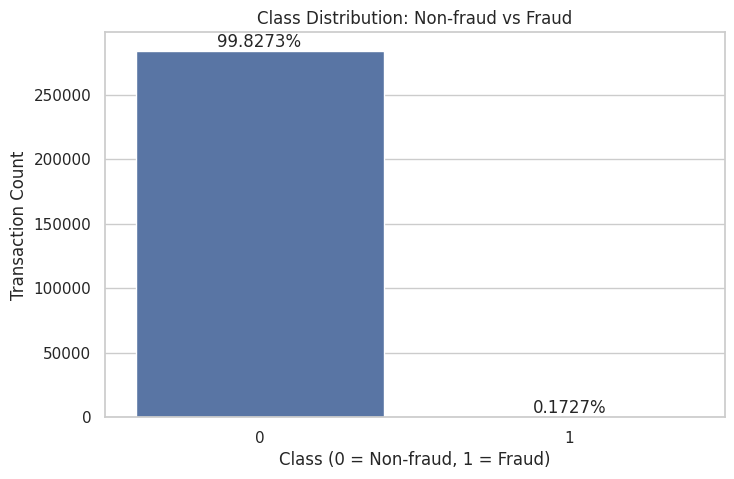

In [18]:
# =============================================================================
# 2.2.4 Analyze Class Distribution
# =============================================================================

class_distribution = df["Class"].value_counts().sort_index().reset_index()
class_distribution.columns = ["Class", "Count"]
class_distribution["Label"] = class_distribution["Class"].map({0: "Non-fraud", 1: "Fraud"})
class_distribution["Percentage"] = (class_distribution["Count"] / len(df) * 100).round(4)

display(class_distribution[["Class", "Label", "Count", "Percentage"]])

plt.figure(figsize=(8, 5))
ax = sns.countplot(data=df, x="Class")
total_count = len(df)

for p in ax.patches:
    height = p.get_height()
    percentage = 100 * height / total_count
    ax.annotate(
        f"{percentage:.4f}%",
        (p.get_x() + p.get_width() / 2, height),
        ha="center",
        va="bottom"
    )

ax.set_title("Class Distribution: Non-fraud vs Fraud")
ax.set_xlabel("Class (0 = Non-fraud, 1 = Fraud)")
ax.set_ylabel("Transaction Count")
plt.show()

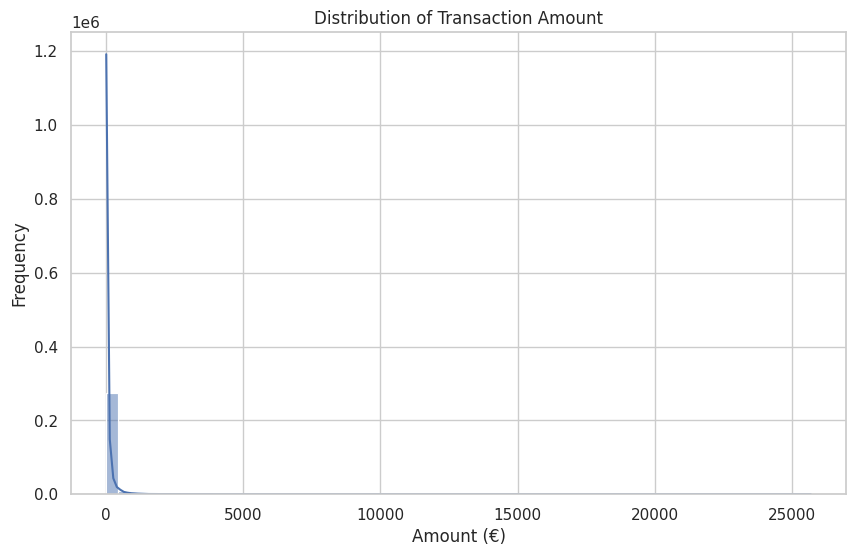

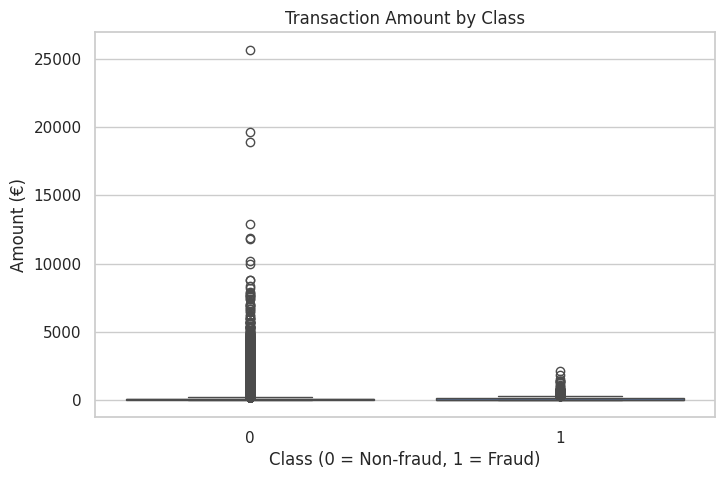

,count,mean,median,std,min,max
Class,,,,,,
0,284315,88.2910,22.0000,250.1051,0.0000,"25,691.1600"
1,492,122.2113,9.2500,256.6833,0.0000,"2,125.8700"


,Metric,Value
0,Q1,5.6000
1,Q3,77.1650
2,IQR,71.5650
3,Lower Bound,-101.7475
4,Upper Bound,184.5125
5,Outlier Count,"31,904.0000"
6,Outlier Percentage,11.2020


In [19]:
# =============================================================================
# 2.2.5 Analyze Transaction Amount
# =============================================================================

# Plot overall amount distribution
plt.figure(figsize=(10, 6))
sns.histplot(df["Amount"], bins=60, kde=True)
plt.title("Distribution of Transaction Amount")
plt.xlabel("Amount (€)")
plt.ylabel("Frequency")
plt.show()

# Compare amount by class
plt.figure(figsize=(8, 5))
sns.boxplot(data=df, x="Class", y="Amount")
plt.title("Transaction Amount by Class")
plt.xlabel("Class (0 = Non-fraud, 1 = Fraud)")
plt.ylabel("Amount (€)")
plt.show()

# Summarize amount statistics by class
amount_by_class = df.groupby("Class")["Amount"].agg(
    ["count", "mean", "median", "std", "min", "max"]
)
display(amount_by_class)

# Calculate outliers using IQR
Q1 = df["Amount"].quantile(0.25)
Q3 = df["Amount"].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

outlier_count = df[(df["Amount"] < lower_bound) | (df["Amount"] > upper_bound)].shape[0]
outlier_percentage = (outlier_count / len(df)) * 100

amount_outlier_summary = pd.DataFrame({
    "Metric": [
        "Q1", "Q3", "IQR", "Lower Bound", "Upper Bound",
        "Outlier Count", "Outlier Percentage"
    ],
    "Value": [
        Q1, Q3, IQR, lower_bound, upper_bound,
        outlier_count, round(outlier_percentage, 4)
    ]
})

display(amount_outlier_summary)

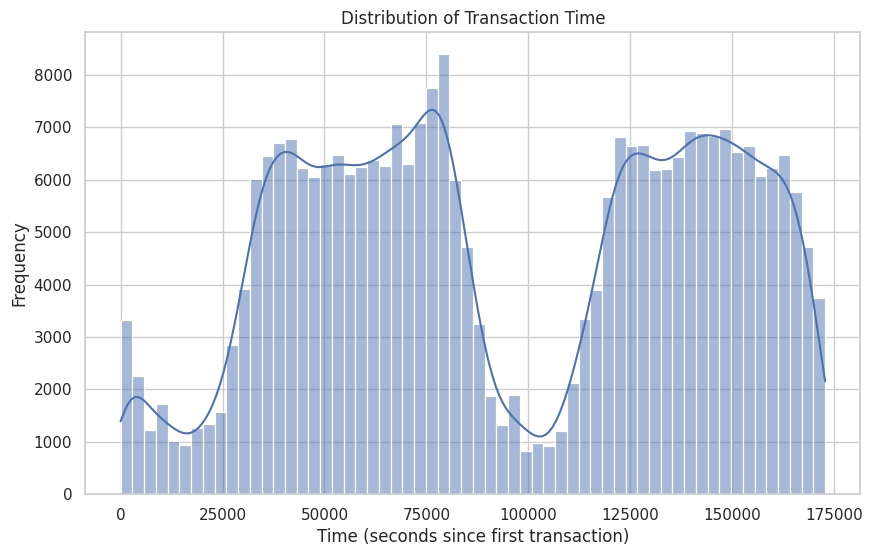

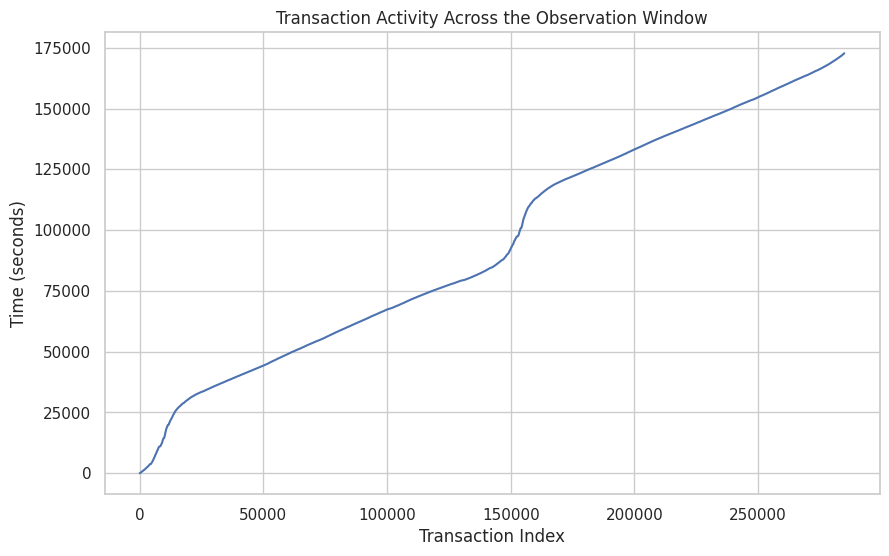

,Hour_Proxy,Transaction_Count
0,0,7695
1,1,4220
2,2,3328
3,3,3492
4,4,2209
5,5,2990
6,6,4101
7,7,7243
8,8,10276
9,9,15838


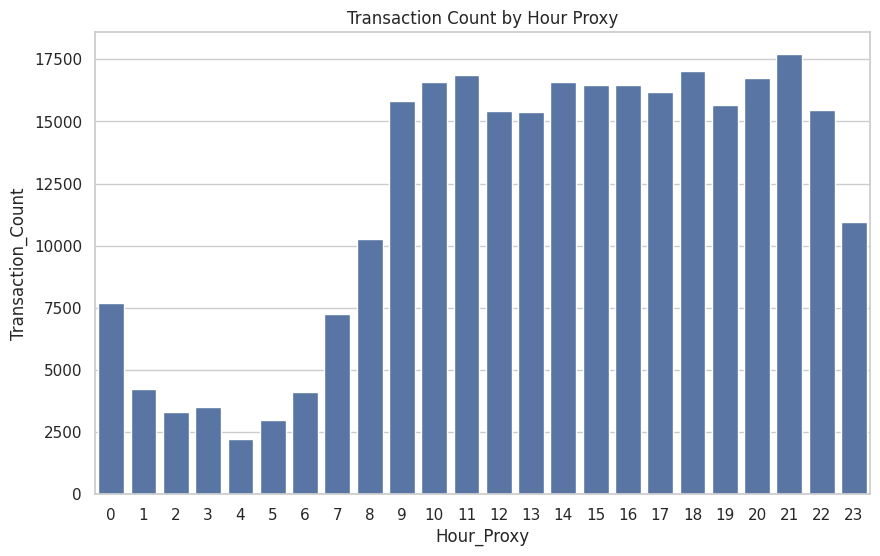

,Hour_Proxy,Transaction_Count,Fraud_Count,Fraud_Rate_Percent
0,0,7695,6,0.0780
1,1,4220,10,0.2370
2,2,3328,57,1.7127
3,3,3492,17,0.4868
4,4,2209,23,1.0412
5,5,2990,11,0.3679
6,6,4101,9,0.2195
7,7,7243,23,0.3175
8,8,10276,9,0.0876
9,9,15838,16,0.1010


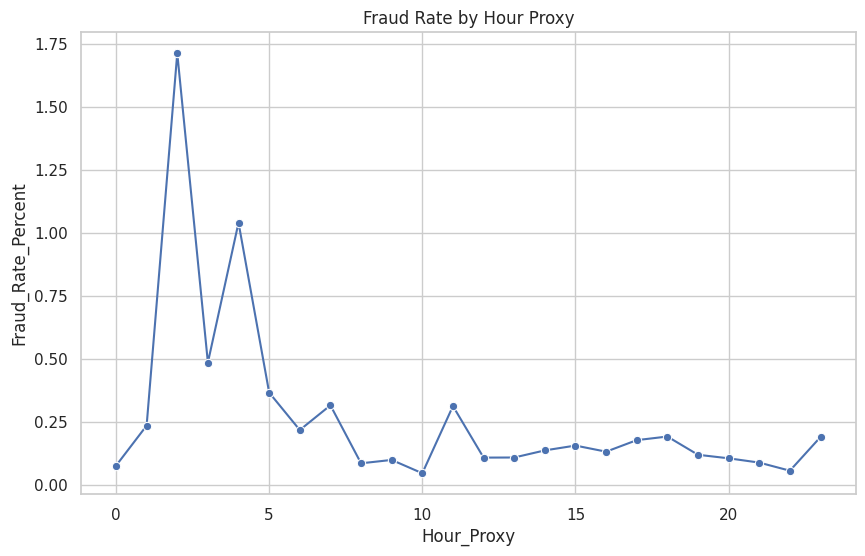

In [20]:
# =============================================================================
# 2.2.6 Analyze Transaction Time
# =============================================================================

# Plot time distribution
plt.figure(figsize=(10, 6))
sns.histplot(df["Time"], bins=60, kde=True)
plt.title("Distribution of Transaction Time")
plt.xlabel("Time (seconds since first transaction)")
plt.ylabel("Frequency")
plt.show()

# Plot transaction activity over time
plt.figure(figsize=(10, 6))
plt.plot(df["Time"].sort_values().values)
plt.title("Transaction Activity Across the Observation Window")
plt.xlabel("Transaction Index")
plt.ylabel("Time (seconds)")
plt.show()

# Create hour proxy
df["Hour_Proxy"] = ((df["Time"] // 3600) % 24).astype(int)

# Summarize hourly transaction count
hourly_transaction_count = df.groupby("Hour_Proxy").size().reset_index(name="Transaction_Count")
display(hourly_transaction_count)

# Plot hourly transaction count
plt.figure(figsize=(10, 6))
sns.barplot(data=hourly_transaction_count, x="Hour_Proxy", y="Transaction_Count")
plt.title("Transaction Count by Hour Proxy")
plt.show()

# Summarize hourly fraud patterns
hourly_fraud_summary = df.groupby("Hour_Proxy")["Class"].agg(["count", "sum"]).reset_index()
hourly_fraud_summary.columns = ["Hour_Proxy", "Transaction_Count", "Fraud_Count"]
hourly_fraud_summary["Fraud_Rate_Percent"] = (
    hourly_fraud_summary["Fraud_Count"] / hourly_fraud_summary["Transaction_Count"] * 100
).round(4)

display(hourly_fraud_summary)

# Plot fraud rate by hour
plt.figure(figsize=(10, 6))
sns.lineplot(data=hourly_fraud_summary, x="Hour_Proxy", y="Fraud_Rate_Percent", marker="o")
plt.title("Fraud Rate by Hour Proxy")
plt.show()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,V11,V12,V13,V14,V15,V16,V17,V18,V19,V20,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
Time,1.0000,0.1174,-0.0106,-0.4196,-0.1053,0.1731,-0.0630,0.0847,-0.0369,-0.0087,0.0306,-0.2477,0.1243,-0.0659,-0.0988,-0.1835,0.0119,-0.0733,0.0904,0.0290,-0.0509,0.0447,0.1441,0.0511,-0.0162,-0.2331,-0.0414,-0.0051,-0.0094,-0.0106,-0.0123
V1,0.1174,1.0000,0.0000,-0.0000,-0.0000,0.0000,-0.0000,-0.0000,-0.0000,-0.0000,0.0000,0.0000,0.0000,-0.0000,-0.0000,0.0000,0.0000,-0.0000,0.0000,0.0000,0.0000,-0.0000,-0.0000,0.0000,-0.0000,-0.0000,-0.0000,0.0000,0.0000,-0.2277,-0.1013
V2,-0.0106,0.0000,1.0000,0.0000,-0.0000,0.0000,0.0000,0.0000,-0.0000,0.0000,-0.0000,0.0000,-0.0000,0.0000,-0.0000,-0.0000,0.0000,-0.0000,0.0000,-0.0000,0.0000,-0.0000,0.0000,0.0000,0.0000,-0.0000,0.0000,-0.0000,-0.0000,-0.5314,0.0913
V3,-0.4196,-0.0000,0.0000,1.0000,0.0000,-0.0000,0.0000,0.0000,-0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,-0.0000,0.0000,-0.0000,-0.0000,0.0000,-0.0000,-0.0000,0.0000,0.0000,-0.2109,-0.1930
V4,-0.1053,-0.0000,-0.0000,0.0000,1.0000,-0.0000,-0.0000,-0.0000,0.0000,0.0000,0.0000,0.0000,-0.0000,0.0000,0.0000,0.0000,-0.0000,-0.0000,-0.0000,-0.0000,-0.0000,-0.0000,-0.0000,0.0000,0.0000,0.0000,-0.0000,0.0000,-0.0000,0.0987,0.1334


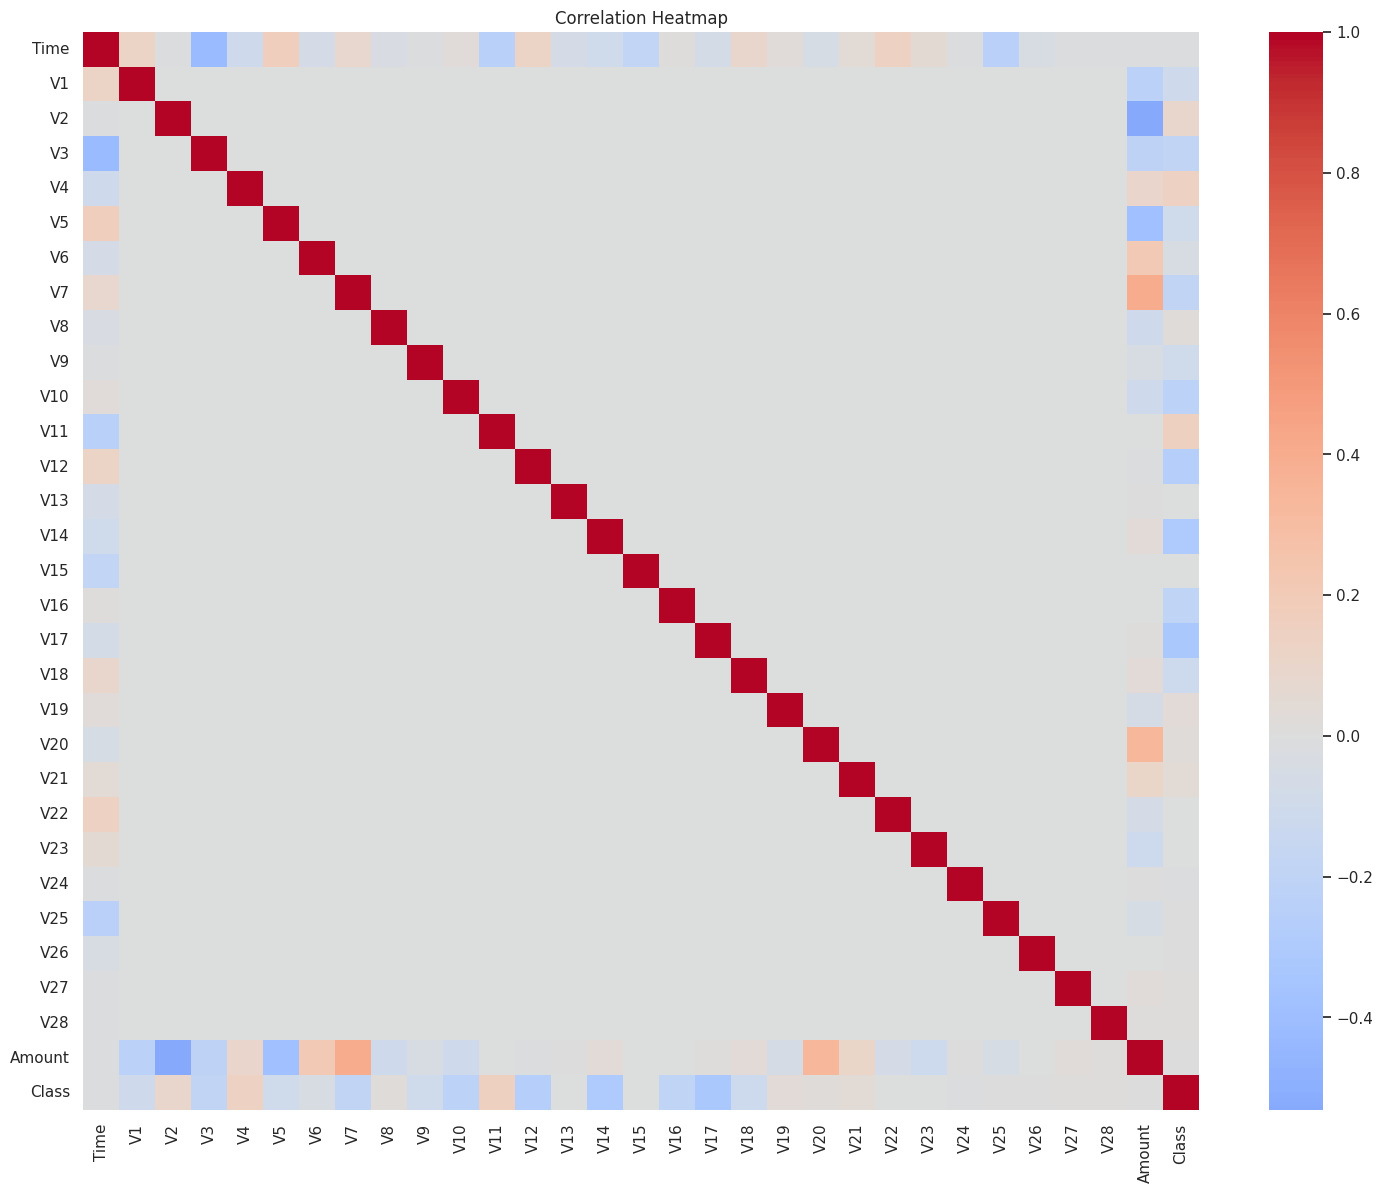

,Variable,Correlation_with_Class
0,V17,-0.3265
1,V14,-0.3025
2,V12,-0.2606
3,V10,-0.2169
4,V16,-0.1965
5,V3,-0.1930
6,V7,-0.1873
7,V11,0.1549
8,V4,0.1334
9,V18,-0.1115


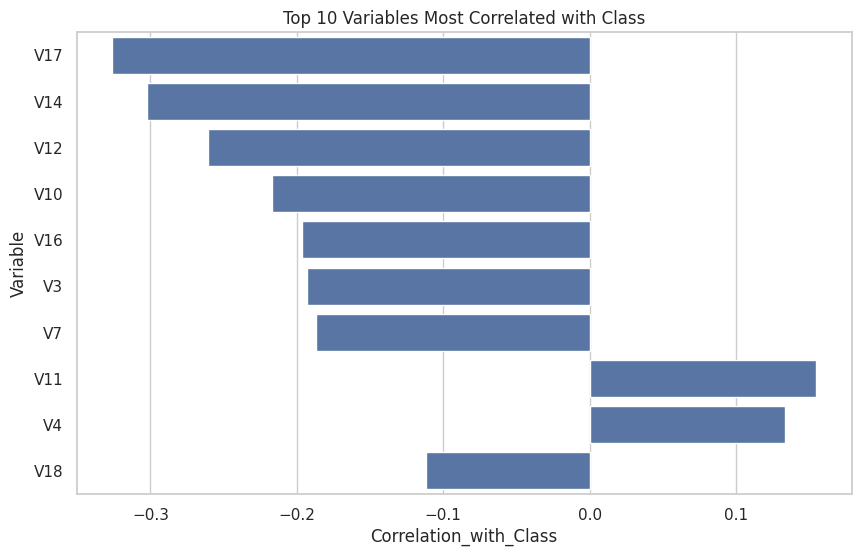

In [21]:
# =============================================================================
# 2.2.7 Analyze Correlation Structure
# =============================================================================

correlation_matrix = df.drop(columns=["Hour_Proxy"], errors="ignore").corr()

# Display correlation matrix preview
display(correlation_matrix.head())

# Plot full heatmap
plt.figure(figsize=(18, 14))
sns.heatmap(correlation_matrix, cmap="coolwarm", center=0)
plt.title("Correlation Heatmap")
plt.show()

# Identify top correlations with target
target_correlations = correlation_matrix["Class"].drop("Class").sort_values(
    key=abs, ascending=False
)
target_correlations_df = target_correlations.reset_index()
target_correlations_df.columns = ["Variable", "Correlation_with_Class"]

display(target_correlations_df.head(15))

# Plot top correlations
plt.figure(figsize=(10, 6))
sns.barplot(
    data=target_correlations_df.head(10),
    x="Correlation_with_Class",
    y="Variable"
)
plt.title("Top 10 Variables Most Correlated with Class")
plt.show()

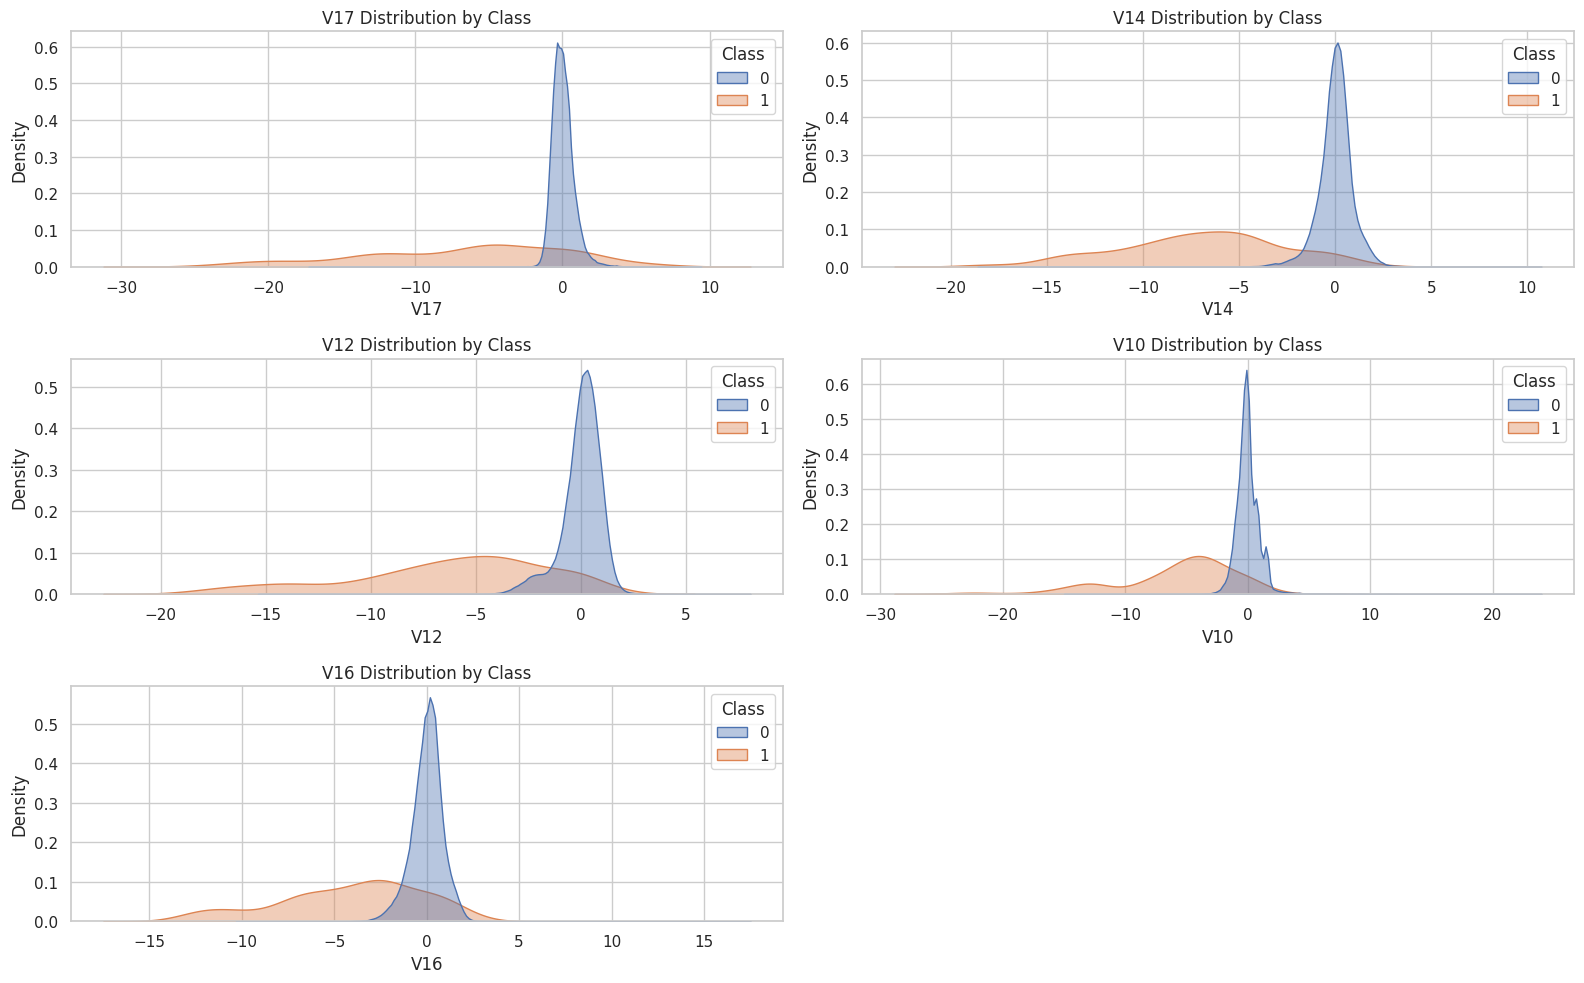

In [22]:
# =============================================================================
# 2.2.8 Examine Key Fraud-Related Feature Distributions
# =============================================================================

top_features = ["V17", "V14", "V12", "V10", "V16"]

plt.figure(figsize=(16, 10))
for i, feature in enumerate(top_features, 1):
    plt.subplot(3, 2, i)
    sns.kdeplot(
        data=df,
        x=feature,
        hue="Class",
        fill=True,
        alpha=0.4,
        common_norm=False
    )
    plt.title(f"{feature} Distribution by Class")

plt.tight_layout()
plt.show()

###**2.3. Data Dictionary**

In [11]:
# =============================================================================
# 2.3.1 Build Core Variables Dictionary Table
# =============================================================================

core_variables_dict = pd.DataFrame({
    "Variable": ["Time", "Amount", "Class"],
    "Type": [str(df["Time"].dtype), str(df["Amount"].dtype), str(df["Class"].dtype)],
    "Description": [
        "Elapsed time since first transaction",
        "Transaction amount (euros)",
        "Fraud label"
    ]
})

display(core_variables_dict)

,Variable,Type,Description
0,Time,float64,Elapsed time since first transaction
1,Amount,float64,Transaction amount (euros)
2,Class,int64,Fraud label


In [12]:
# =============================================================================
# 2.3.2 Build PCA Variable Dictionary Table
# =============================================================================

pca_variables = [f"V{i}" for i in range(1, 29)]

pca_variables_dict = pd.DataFrame({
    "Variable": pca_variables,
    "Type": [str(df[col].dtype) for col in pca_variables],
    "Description": ["Anonymized PCA feature"] * 28
})

display(pca_variables_dict)

,Variable,Type,Description
0,V1,float64,Anonymized PCA feature
1,V2,float64,Anonymized PCA feature
2,V3,float64,Anonymized PCA feature
3,V4,float64,Anonymized PCA feature
4,V5,float64,Anonymized PCA feature
5,V6,float64,Anonymized PCA feature
6,V7,float64,Anonymized PCA feature
7,V8,float64,Anonymized PCA feature
8,V9,float64,Anonymized PCA feature
9,V10,float64,Anonymized PCA feature


In [13]:
# =============================================================================
# 2.3.3 Export Data Dictionary Tables
# =============================================================================

os.makedirs("results", exist_ok=True)

core_variables_dict.to_csv("results/core_variables_dict.csv", index=False)
pca_variables_dict.to_csv("results/pca_variables_dict.csv", index=False)

print("Data dictionary exported successfully.")

Data dictionary exported successfully.


##**Step 3: Data Preprocessing, EDA, and Feature Engineering**

####Prepare the dataset for modeling through data cleaning, feature engineering, exploratory data analysis, feature selection, and dimensionality reduction.
####📑 **Full Discussion:** *Full narrative discussion is provided in the accompanying Capstone Report.*

In [23]:
# =============================================================================
# Setup
# =============================================================================

import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.feature_selection import SelectKBest, mutual_info_classif
from sklearn.ensemble import RandomForestClassifier
from sklearn.decomposition import PCA

warnings.filterwarnings("ignore")

# Set display options
pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 200)
pd.set_option("display.float_format", "{:,.4f}".format)

# Set plot defaults
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)

# Set reproducibility controls
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

###**3.1. Data Preprocesing**

In [24]:
# =============================================================================
# 3.1.1 Create Step 3 Working Dataset from Deduplicated Data
# =============================================================================

# Create Step 3 working copy
df_step3 = df_unique.copy()

# Confirm row and column counts
step3_shape_summary = pd.DataFrame({
    "Check": ["Original rows", "Deduplicated rows", "Step 3 rows", "Step 3 columns"],
    "Result": [df.shape[0], df_unique.shape[0], df_step3.shape[0], df_step3.shape[1]]
})

display(step3_shape_summary)

,Check,Result
0,Original rows,284807
1,Deduplicated rows,283726
2,Step 3 rows,283726
3,Step 3 columns,32


In [26]:
# =============================================================================
# 3.1.2 Verify Nulls, Duplicates, and Treatment Decisions
# =============================================================================

# Summarize null and duplicate checks
step3_quality_checks = pd.DataFrame({
    "Check": [
        "Missing values in Step 3 dataset",
        "Columns with missing values",
        "Duplicate rows remaining in Step 3 dataset"
    ],
    "Result": [
        int(df_step3.isnull().sum().sum()),
        int((df_step3.isnull().sum() > 0).sum()),
        int(df_step3.duplicated().sum())
    ],
    "Treatment_Decision": [
        "No imputation required",
        "No action required",
        "Already removed via Step 2 deduplication"
    ]
})

display(step3_quality_checks)

,Check,Result,Treatment_Decision
0,Missing values in Step 3 dataset,0,No imputation required
1,Columns with missing values,0,No action required
2,Duplicate rows remaining in Step 3 dataset,0,Already removed via Step 2 deduplication


In [27]:
# =============================================================================
# 3.1.3 Confirm Outlier Retention Strategy for Amount
# =============================================================================

# Compute IQR-based outlier summary for Amount
q1_amount = df_step3["Amount"].quantile(0.25)
q3_amount = df_step3["Amount"].quantile(0.75)
iqr_amount = q3_amount - q1_amount
lower_bound_amount = q1_amount - 1.5 * iqr_amount
upper_bound_amount = q3_amount + 1.5 * iqr_amount

amount_outlier_count = df_step3[
    (df_step3["Amount"] < lower_bound_amount) |
    (df_step3["Amount"] > upper_bound_amount)
].shape[0]

amount_outlier_summary = pd.DataFrame({
    "Metric": [
        "Q1",
        "Q3",
        "IQR",
        "Lower Bound",
        "Upper Bound",
        "Outlier Count",
        "Outlier Percentage",
        "Treatment Decision"
    ],
    "Value": [
        q1_amount,
        q3_amount,
        iqr_amount,
        lower_bound_amount,
        upper_bound_amount,
        amount_outlier_count,
        round(amount_outlier_count / len(df_step3) * 100, 4),
        "Retain outliers; transform and scale later"
    ]
})

display(amount_outlier_summary)

,Metric,Value
0,Q1,5.6000
1,Q3,77.5100
2,IQR,71.9100
3,Lower Bound,-102.2650
4,Upper Bound,185.3750
5,Outlier Count,31685
6,Outlier Percentage,11.1675
7,Treatment Decision,Retain outliers; transform and scale later


###**3.2. Feature Engineering**

In [29]:
# Create log-transformed amount
df_step3["Log_Amount"] = np.log1p(df_step3["Amount"])

# Create hour-of-day proxy
df_step3["Hour_Proxy"] = ((df_step3["Time"] // 3600) % 24).astype(int)

# Create cyclical hour features
df_step3["Hour_Sin"] = np.sin(2 * np.pi * df_step3["Hour_Proxy"] / 24)
df_step3["Hour_Cos"] = np.cos(2 * np.pi * df_step3["Hour_Proxy"] / 24)

# Create high-amount flag
amount_95th = df_step3["Amount"].quantile(0.95)
df_step3["Is_High_Amount"] = (df_step3["Amount"] >= amount_95th).astype(int)

# Create night-transaction flag
df_step3["Is_Night"] = df_step3["Hour_Proxy"].isin([0, 1, 2, 3, 4, 5]).astype(int)

# Define engineered feature list
engineered_features = [
    "Log_Amount",
    "Hour_Proxy",
    "Hour_Sin",
    "Hour_Cos",
    "Is_High_Amount",
    "Is_Night"
]

# Preview engineered variables
display(df_step3[["Time", "Amount"] + engineered_features + ["Class"]].head())

# Summarize engineered variables with features as columns
engineered_feature_summary = df_step3[engineered_features].describe()

display(engineered_feature_summary)

,Time,Amount,Log_Amount,Hour_Proxy,Hour_Sin,Hour_Cos,Is_High_Amount,Is_Night,Class
0,0.0000,149.6200,5.0148,0,0.0000,1.0000,0,1,0
1,0.0000,2.6900,1.3056,0,0.0000,1.0000,0,1,0
2,1.0000,378.6600,5.9393,0,0.0000,1.0000,1,1,0
3,1.0000,123.5000,4.8243,0,0.0000,1.0000,0,1,0
4,2.0000,69.9900,4.2625,0,0.0000,1.0000,0,1,0


,Log_Amount,Hour_Proxy,Hour_Sin,Hour_Cos,Is_High_Amount,Is_Night
count,"283,726.0000","283,726.0000","283,726.0000","283,726.0000","283,726.0000","283,726.0000"
mean,3.1538,14.0456,-0.2443,-0.1745,0.0500,0.0840
std,1.6571,5.8348,0.6506,0.6975,0.2180,0.2774
min,0.0000,0.0000,-1.0000,-1.0000,0.0000,0.0000
25%,1.8871,10.0000,-0.8660,-0.8660,0.0000,0.0000
50%,3.1355,15.0000,-0.5000,-0.2588,0.0000,0.0000
75%,4.3632,19.0000,0.2588,0.5000,0.0000,0.0000
max,10.1539,23.0000,1.0000,1.0000,1.0000,1.0000


###**3.3. Exploratory Data Analysis (Engineered Features)**

,count,mean,median,std,min,max
Class,,,,,,
0,283253,3.1543,3.1355,1.6560,0.0000,10.1539
1,473,2.8375,2.3814,2.2127,0.0000,7.6624


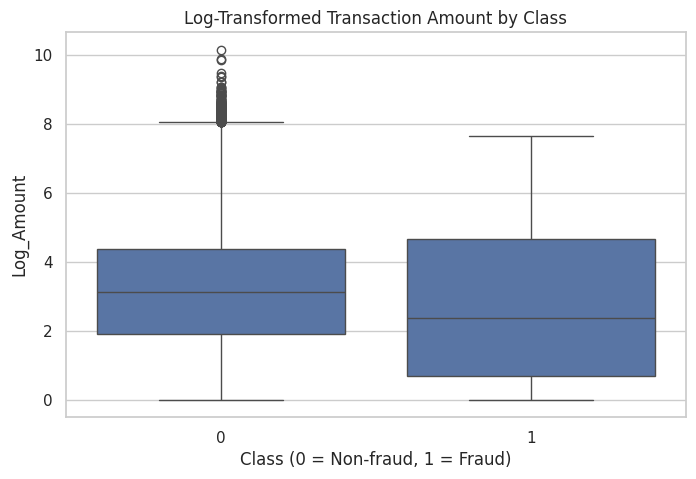

In [30]:
# =============================================================================
# 3.3.1 Analyze Log_Amount by Class
# =============================================================================

# Summarize Log_Amount by class
log_amount_by_class = df_step3.groupby("Class")["Log_Amount"].agg(
    ["count", "mean", "median", "std", "min", "max"]
)

display(log_amount_by_class)

# Plot Log_Amount by class
plt.figure(figsize=(8, 5))
sns.boxplot(data=df_step3, x="Class", y="Log_Amount")
plt.title("Log-Transformed Transaction Amount by Class")
plt.xlabel("Class (0 = Non-fraud, 1 = Fraud)")
plt.ylabel("Log_Amount")
plt.show()

,Is_High_Amount,Transaction_Count,Fraud_Count,Fraud_Rate
0,0,269539,431,0.0016
1,1,14187,42,0.0030


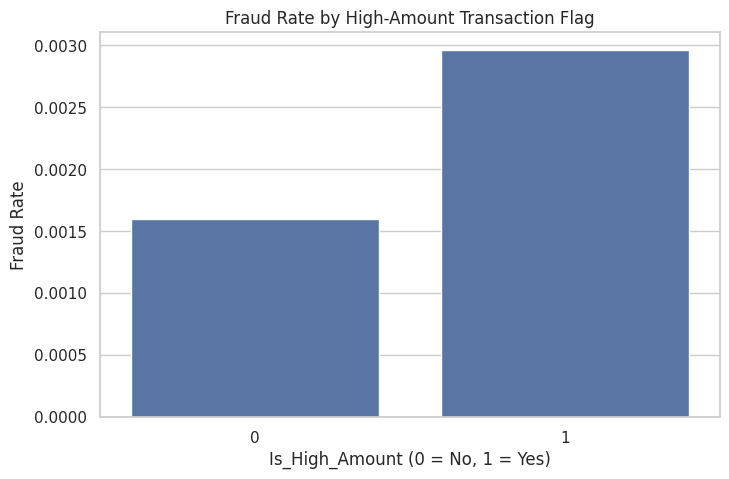

In [31]:
# =============================================================================
# 3.3.2 Analyze Is_High_Amount and Fraud Rate
# =============================================================================

# Summarize fraud outcomes by high-amount flag
fraud_rate_by_amount_flag = (
    df_step3.groupby("Is_High_Amount")["Class"]
    .agg(["count", "sum", "mean"])
    .reset_index()
    .rename(columns={
        "count": "Transaction_Count",
        "sum": "Fraud_Count",
        "mean": "Fraud_Rate"
    })
)

display(fraud_rate_by_amount_flag)

# Plot fraud rate by high-amount flag
plt.figure(figsize=(8, 5))
sns.barplot(data=fraud_rate_by_amount_flag, x="Is_High_Amount", y="Fraud_Rate")
plt.title("Fraud Rate by High-Amount Transaction Flag")
plt.xlabel("Is_High_Amount (0 = No, 1 = Yes)")
plt.ylabel("Fraud Rate")
plt.show()

,Hour_Proxy,Transaction_Count,Fraud_Count,Fraud_Rate
0,0,7647,6,0.0008
1,1,4208,10,0.0024
2,2,3308,48,0.0145
3,3,3487,17,0.0049
4,4,2204,23,0.0104
5,5,2988,11,0.0037
6,6,4082,9,0.0022
7,7,7233,23,0.0032
8,8,10232,9,0.0009
9,9,15767,16,0.0010


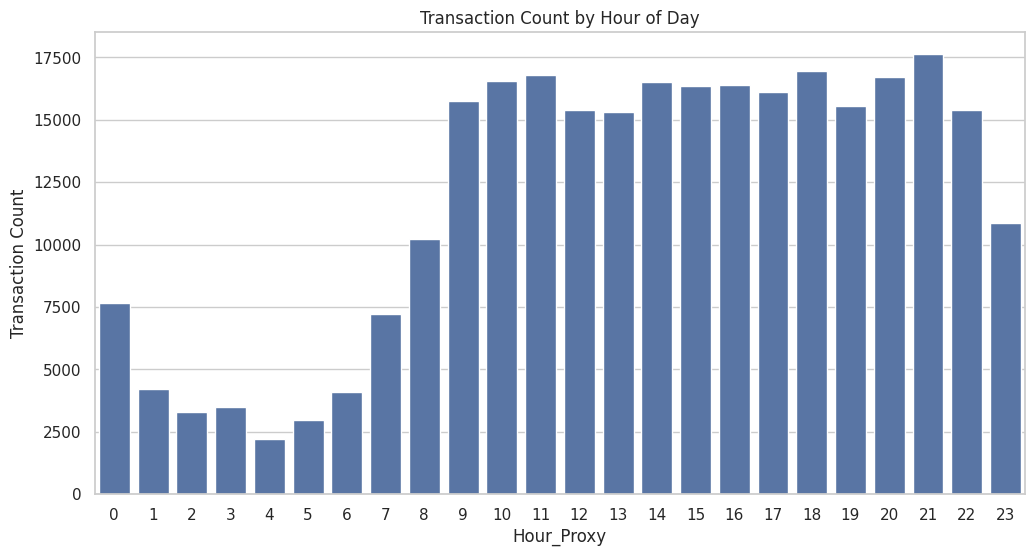

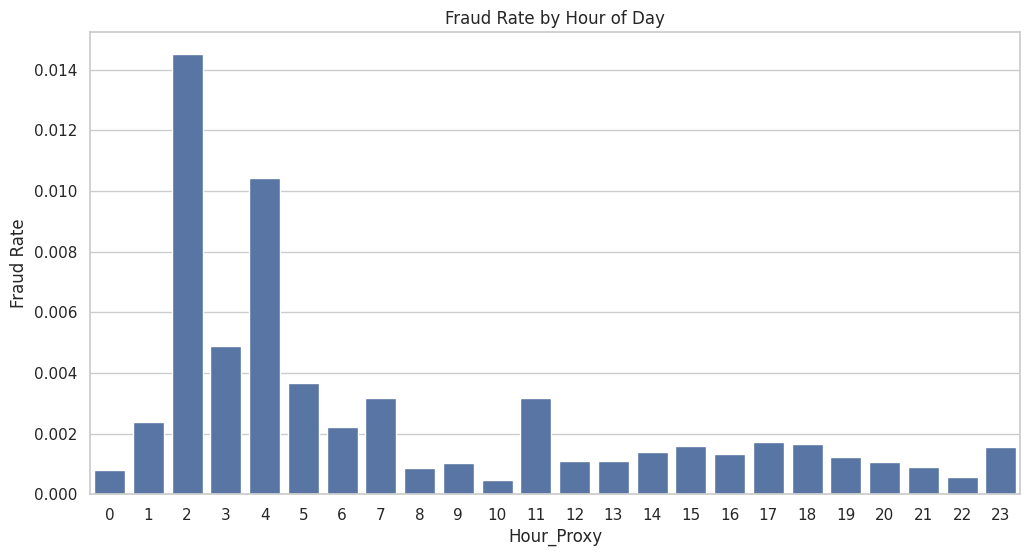

In [37]:
# =============================================================================
# 3.3.3 Analyze Fraud Count, Transaction Count, and Fraud Rate by Hour_Proxy
# =============================================================================

# Summarize hourly transaction and fraud patterns
hourly_fraud_summary = (
    df_step3.groupby("Hour_Proxy")["Class"]
    .agg(["count", "sum", "mean"])
    .reset_index()
    .rename(columns={
        "count": "Transaction_Count",
        "sum": "Fraud_Count",
        "mean": "Fraud_Rate"
    })
)

display(hourly_fraud_summary)

# Plot transaction count by hour
plt.figure(figsize=(12, 6))
sns.barplot(data=hourly_fraud_summary, x="Hour_Proxy", y="Transaction_Count")
plt.title("Transaction Count by Hour of Day")
plt.xlabel("Hour_Proxy")
plt.ylabel("Transaction Count")
plt.xticks(range(24))
plt.show()

# Plot fraud rate by hour
plt.figure(figsize=(12, 6))
sns.barplot(data=hourly_fraud_summary, x="Hour_Proxy", y="Fraud_Rate")
plt.title("Fraud Rate by Hour of Day")
plt.xlabel("Hour_Proxy")
plt.ylabel("Fraud Rate")
plt.xticks(range(24))
plt.show()

,Is_Night,Transaction_Count,Fraud_Count,Fraud_Rate
0,0,259884,358,0.0014
1,1,23842,115,0.0048


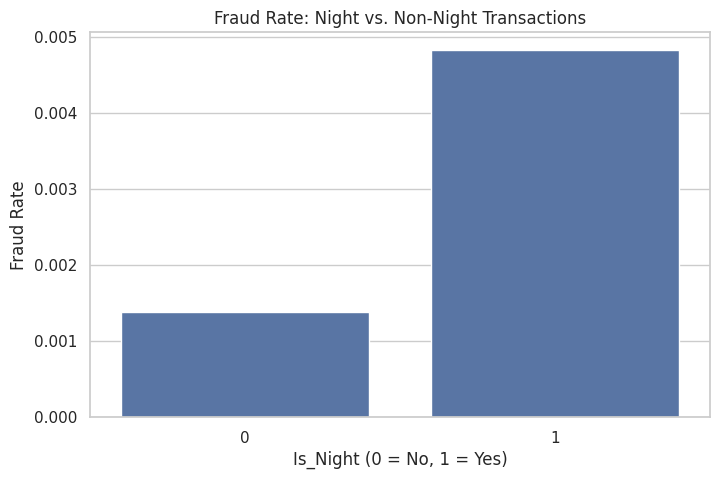

In [38]:
# =============================================================================
# 3.3.4 Analyze Is_Night and Fraud Rate
# =============================================================================

# Summarize fraud outcomes by night flag
fraud_rate_by_night = (
    df_step3.groupby("Is_Night")["Class"]
    .agg(["count", "sum", "mean"])
    .reset_index()
    .rename(columns={
        "count": "Transaction_Count",
        "sum": "Fraud_Count",
        "mean": "Fraud_Rate"
    })
)

display(fraud_rate_by_night)

# Plot fraud rate by night flag
plt.figure(figsize=(8, 5))
sns.barplot(data=fraud_rate_by_night, x="Is_Night", y="Fraud_Rate")
plt.title("Fraud Rate: Night vs. Non-Night Transactions")
plt.xlabel("Is_Night (0 = No, 1 = Yes)")
plt.ylabel("Fraud Rate")
plt.show()

###**3.4. Model Preparation**

In [39]:
# =============================================================================
# 3.4.1 Build Feature Matrix and Target Variable
# =============================================================================

# Define target variable
y = df_step3["Class"]

# Define full predictor list
feature_columns = [
    "Time", "Amount",
    "V1", "V2", "V3", "V4", "V5", "V6", "V7", "V8", "V9", "V10",
    "V11", "V12", "V13", "V14", "V15", "V16", "V17", "V18", "V19",
    "V20", "V21", "V22", "V23", "V24", "V25", "V26", "V27", "V28",
    "Log_Amount", "Hour_Proxy", "Hour_Sin", "Hour_Cos",
    "Is_High_Amount", "Is_Night"
]

# Build feature matrix
X = df_step3[feature_columns]

# Confirm dimensions and class balance
print("Feature matrix shape:", X.shape)
print("Target variable shape:", y.shape)
print("Number of predictor variables:", len(feature_columns))
print("\nTarget distribution:")
display(y.value_counts().sort_index())

# Preview predictors
display(X.head())

Feature matrix shape: (283726, 36)
Target variable shape: (283726,)
Number of predictor variables: 36

Target distribution:


,count
Class,
0,283253
1,473


,Time,Amount,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,V11,V12,V13,V14,V15,V16,V17,V18,V19,V20,V21,V22,V23,V24,V25,V26,V27,V28,Log_Amount,Hour_Proxy,Hour_Sin,Hour_Cos,Is_High_Amount,Is_Night
0,0.0000,149.6200,-1.3598,-0.0728,2.5363,1.3782,-0.3383,0.4624,0.2396,0.0987,0.3638,0.0908,-0.5516,-0.6178,-0.9914,-0.3112,1.4682,-0.4704,0.2080,0.0258,0.4040,0.2514,-0.0183,0.2778,-0.1105,0.0669,0.1285,-0.1891,0.1336,-0.0211,5.0148,0,0.0000,1.0000,0,1
1,0.0000,2.6900,1.1919,0.2662,0.1665,0.4482,0.0600,-0.0824,-0.0788,0.0851,-0.2554,-0.1670,1.6127,1.0652,0.4891,-0.1438,0.6356,0.4639,-0.1148,-0.1834,-0.1458,-0.0691,-0.2258,-0.6387,0.1013,-0.3398,0.1672,0.1259,-0.0090,0.0147,1.3056,0,0.0000,1.0000,0,1
2,1.0000,378.6600,-1.3584,-1.3402,1.7732,0.3798,-0.5032,1.8005,0.7915,0.2477,-1.5147,0.2076,0.6245,0.0661,0.7173,-0.1659,2.3459,-2.8901,1.1100,-0.1214,-2.2619,0.5250,0.2480,0.7717,0.9094,-0.6893,-0.3276,-0.1391,-0.0554,-0.0598,5.9393,0,0.0000,1.0000,1,1
3,1.0000,123.5000,-0.9663,-0.1852,1.7930,-0.8633,-0.0103,1.2472,0.2376,0.3774,-1.3870,-0.0550,-0.2265,0.1782,0.5078,-0.2879,-0.6314,-1.0596,-0.6841,1.9658,-1.2326,-0.2080,-0.1083,0.0053,-0.1903,-1.1756,0.6474,-0.2219,0.0627,0.0615,4.8243,0,0.0000,1.0000,0,1
4,2.0000,69.9900,-1.1582,0.8777,1.5487,0.4030,-0.4072,0.0959,0.5929,-0.2705,0.8177,0.7531,-0.8228,0.5382,1.3459,-1.1197,0.1751,-0.4514,-0.2370,-0.0382,0.8035,0.4085,-0.0094,0.7983,-0.1375,0.1413,-0.2060,0.5023,0.2194,0.2152,4.2625,0,0.0000,1.0000,0,1


In [40]:
# =============================================================================
# 3.4.2 Perform Stratified Train-Test Split
# =============================================================================

# Split predictors and target
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=RANDOM_STATE,
    stratify=y
)

# Summarize split results
print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)

train_class_dist = pd.DataFrame({
    "Count": y_train.value_counts().sort_index(),
    "Proportion": y_train.value_counts(normalize=True).sort_index()
})

test_class_dist = pd.DataFrame({
    "Count": y_test.value_counts().sort_index(),
    "Proportion": y_test.value_counts(normalize=True).sort_index()
})

print("\nTraining set class distribution:")
display(train_class_dist)

print("Test set class distribution:")
display(test_class_dist)

X_train shape: (226980, 36)
X_test shape: (56746, 36)
y_train shape: (226980,)
y_test shape: (56746,)

Training set class distribution:


,Count,Proportion
Class,,
0,226602,0.9983
1,378,0.0017


Test set class distribution:


,Count,Proportion
Class,,
0,56651,0.9983
1,95,0.0017


In [41]:
# =============================================================================
# 3.4.3 Apply Feature Scaling
# =============================================================================

# Initialize scaler
scaler = StandardScaler()

# Fit scaler on training data and transform both datasets
X_train_scaled_array = scaler.fit_transform(X_train)
X_test_scaled_array = scaler.transform(X_test)

# Rebuild scaled DataFrames to preserve labels and indices
X_train_scaled = pd.DataFrame(
    X_train_scaled_array,
    columns=X_train.columns,
    index=X_train.index
)

X_test_scaled = pd.DataFrame(
    X_test_scaled_array,
    columns=X_test.columns,
    index=X_test.index
)

# Confirm scaling outputs
print("X_train_scaled shape:", X_train_scaled.shape)
print("X_test_scaled shape:", X_test_scaled.shape)

display(X_train_scaled.head())

scaled_summary = X_train_scaled[
    ["Time", "Amount", "Log_Amount", "Hour_Proxy", "Hour_Sin", "Hour_Cos"]
].agg(["mean", "std"]).T

display(scaled_summary)

X_train_scaled shape: (226980, 36)
X_test_scaled shape: (56746, 36)


,Time,Amount,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,V11,V12,V13,V14,V15,V16,V17,V18,V19,V20,V21,V22,V23,V24,V25,V26,V27,V28,Log_Amount,Hour_Proxy,Hour_Sin,Hour_Cos,Is_High_Amount,Is_Night
226238,1.0455,-0.2294,1.1472,-1.0420,-1.4288,-1.8178,0.7272,2.6957,-1.4893,0.7357,-1.1527,1.4629,-0.2314,-0.7111,0.3664,-0.3268,0.3108,-0.6627,0.4533,-0.2186,-0.3918,-0.4272,-0.2086,-0.0682,0.4454,1.1302,-0.4204,-0.3313,0.0928,-0.1562,0.2055,0.3338,-0.9553,-0.4659,-0.2292,-0.3018
134253,-0.2987,-0.3312,-0.6779,0.9919,0.3947,-0.0256,-0.3012,-0.7282,0.1756,0.6291,-1.1563,-0.4477,1.4107,1.7759,1.2625,0.9057,-0.2921,0.4492,-0.3140,-0.4130,0.4814,-0.0898,-0.3322,-1.3071,0.5180,0.8511,-1.3673,-0.5543,-0.0499,0.1538,-0.6508,1.3631,-0.3926,1.4926,-0.2292,-0.3018
186465,0.6784,-0.2988,0.9777,0.0162,-1.3867,0.0927,0.8506,0.4588,-0.0199,0.1544,0.2621,-0.4618,1.5048,1.0471,0.4792,-0.7208,1.0535,-0.3192,0.9417,-0.1898,-1.2233,-0.2780,0.4050,1.5127,-0.0713,-2.7889,0.2029,0.0155,0.1113,-0.1658,-0.2335,-0.5240,0.7741,-1.1340,-0.2292,-0.3018
149493,-0.0749,-0.2892,0.9276,0.1953,0.2087,2.7399,0.0320,0.7723,-0.6135,0.2000,0.6255,1.0705,1.3127,-1.7888,2.1926,1.3007,-2.2291,1.5370,-0.5629,0.9823,-2.0822,-0.3011,0.1908,0.9668,0.2786,1.1603,-0.4079,-0.0214,-0.0497,-0.1196,-0.1505,-2.2396,0.7741,1.6359,-0.2292,3.3133
18461,-1.3767,-0.2620,0.6952,-0.6761,0.3637,-1.0908,-0.8825,0.2096,-1.0026,0.1822,-1.9116,1.3930,1.7059,0.0145,0.3325,-0.0451,0.5165,-0.7566,0.9348,-0.7687,-0.7282,-0.4771,-0.4736,-0.8787,0.4043,-0.5682,-0.1237,-0.9139,0.1558,0.0373,0.0379,-1.0387,1.7076,-0.4659,-0.2292,-0.3018


,mean,std
Time,-0.0000,1.0000
Amount,0.0000,1.0000
Log_Amount,-0.0000,1.0000
Hour_Proxy,-0.0000,1.0000
Hour_Sin,0.0000,1.0000
Hour_Cos,-0.0000,1.0000


###**3.5. Feature Selection**

In [42]:
# =============================================================================
# 3.5.1 Run Filter-Based Feature Selection Using Mutual Information
# =============================================================================

# Select top-k features using mutual information
k = 20
selector = SelectKBest(score_func=mutual_info_classif, k=k)
selector.fit(X_train_scaled, y_train)

# Extract selected features and MI scores
selected_mask = selector.get_support()
selected_features = X_train_scaled.columns[selected_mask].tolist()

mi_scores_df = pd.DataFrame({
    "Feature": X_train_scaled.columns,
    "Mutual_Information_Score": selector.scores_
}).sort_values(by="Mutual_Information_Score", ascending=False).reset_index(drop=True)

mi_scores_df["MI_Rank"] = mi_scores_df.index + 1

# Transform training and test sets
X_train_selected = pd.DataFrame(
    selector.transform(X_train_scaled),
    columns=selected_features,
    index=X_train_scaled.index
)

X_test_selected = pd.DataFrame(
    selector.transform(X_test_scaled),
    columns=selected_features,
    index=X_test_scaled.index
)

# Display selection results
print("Number of selected features:", len(selected_features))
print("\nSelected features:")
print(selected_features)

display(mi_scores_df.head(20))

print("X_train_selected shape:", X_train_selected.shape)
print("X_test_selected shape:", X_test_selected.shape)

Number of selected features: 20

Selected features:
['V2', 'V3', 'V4', 'V6', 'V7', 'V9', 'V10', 'V11', 'V12', 'V14', 'V16', 'V17', 'V18', 'V21', 'V27', 'Hour_Proxy', 'Hour_Sin', 'Hour_Cos', 'Is_High_Amount', 'Is_Night']


,Feature,Mutual_Information_Score,MI_Rank
0,Is_Night,0.0161,1
1,Is_High_Amount,0.0089,2
2,V17,0.0080,3
3,V14,0.0079,4
4,V10,0.0073,5
5,V12,0.0073,6
6,V11,0.0066,7
7,V16,0.0059,8
8,V3,0.0047,9
9,V4,0.0046,10


X_train_selected shape: (226980, 20)
X_test_selected shape: (56746, 20)


,Feature,RF_Importance,RF_Rank
0,V17,0.2050,1
1,V12,0.1291,2
2,V14,0.1219,3
3,V10,0.0982,4
4,V16,0.0807,5
5,V11,0.0671,6
6,V9,0.0437,7
7,V18,0.0380,8
8,V7,0.0344,9
9,V4,0.0343,10


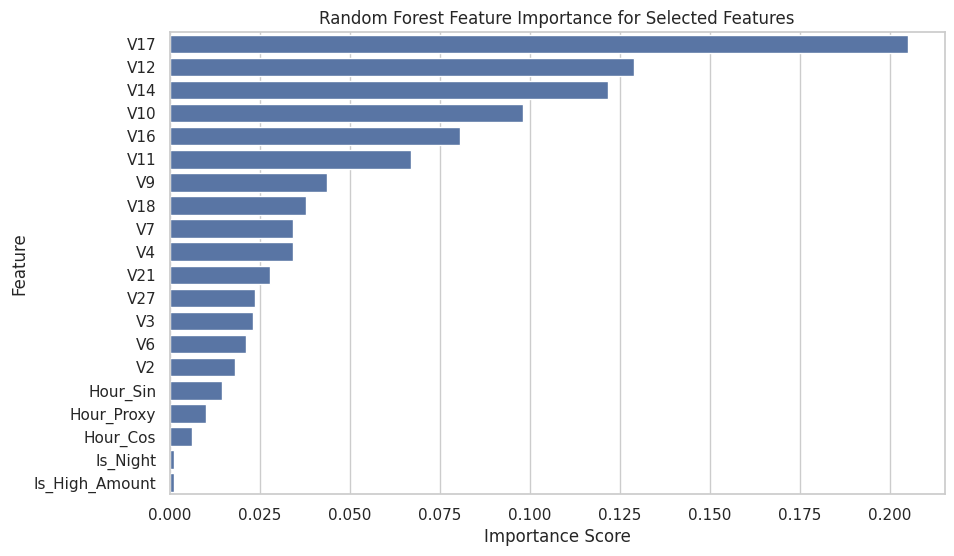

In [43]:
# =============================================================================
# 3.5.2 Validate Selected Features Using Random Forest Importance
# =============================================================================

# Fit Random Forest on selected training features
rf_feature_validator = RandomForestClassifier(
    n_estimators=100,
    random_state=RANDOM_STATE,
    n_jobs=-1
)

rf_feature_validator.fit(X_train_selected, y_train)

# Summarize Random Forest importance scores
rf_importance_df = pd.DataFrame({
    "Feature": X_train_selected.columns,
    "RF_Importance": rf_feature_validator.feature_importances_
}).sort_values(by="RF_Importance", ascending=False).reset_index(drop=True)

rf_importance_df["RF_Rank"] = rf_importance_df.index + 1

# Display Random Forest validation results
display(rf_importance_df)

# Plot Random Forest importances
plt.figure(figsize=(10, 6))
sns.barplot(data=rf_importance_df, x="RF_Importance", y="Feature")
plt.title("Random Forest Feature Importance for Selected Features")
plt.xlabel("Importance Score")
plt.ylabel("Feature")
plt.show()

In [44]:
# =============================================================================
# 3.5.3 Create Feature Comparison Table
# =============================================================================

# Combine MI and RF rankings
feature_comparison_df = (
    mi_scores_df[["Feature", "MI_Rank", "Mutual_Information_Score"]]
    .merge(
        rf_importance_df[["Feature", "RF_Rank", "RF_Importance"]],
        on="Feature",
        how="inner"
    )
    .sort_values(by="MI_Rank")
    .reset_index(drop=True)
)

display(feature_comparison_df)

,Feature,MI_Rank,Mutual_Information_Score,RF_Rank,RF_Importance
0,Is_Night,1,0.0161,19,0.0012
1,Is_High_Amount,2,0.0089,20,0.0012
2,V17,3,0.0080,1,0.2050
3,V14,4,0.0079,3,0.1219
4,V10,5,0.0073,4,0.0982
5,V12,6,0.0073,2,0.1291
6,V11,7,0.0066,6,0.0671
7,V16,8,0.0059,5,0.0807
8,V3,9,0.0047,13,0.0231
9,V4,10,0.0046,10,0.0343


###**3.6. Dimensionality Reduction**

In [45]:
# =============================================================================
# 3.6.1 Apply PCA to Selected Features
# =============================================================================

# Fit PCA to retain at least 95% explained variance
pca = PCA(n_components=0.95, random_state=RANDOM_STATE)

X_train_pca_array = pca.fit_transform(X_train_selected)
X_test_pca_array = pca.transform(X_test_selected)

# Rebuild PCA DataFrames
pca_columns = [f"PC{i+1}" for i in range(X_train_pca_array.shape[1])]

X_train_pca = pd.DataFrame(
    X_train_pca_array,
    columns=pca_columns,
    index=X_train_selected.index
)

X_test_pca = pd.DataFrame(
    X_test_pca_array,
    columns=pca_columns,
    index=X_test_selected.index
)

In [47]:
# =============================================================================
# 3.6.2 Summarize Explained Variance and Retained Components
# =============================================================================

# Compute explained variance summaries
explained_variance_ratio = pca.explained_variance_ratio_
cumulative_variance = np.cumsum(explained_variance_ratio)

pca_summary = pd.DataFrame({
    "Principal_Component": pca_columns,
    "Explained_Variance_Ratio": explained_variance_ratio,
    "Cumulative_Explained_Variance": cumulative_variance
})

print("Original number of selected features:", X_train_selected.shape[1])
print("Number of principal components retained:", X_train_pca.shape[1])
print(f"Total explained variance retained: {cumulative_variance[-1]:.4f}")
print("X_train_pca shape:", X_train_pca.shape)
print("X_test_pca shape:", X_test_pca.shape)

display(pca_summary)

Original number of selected features: 20
Number of principal components retained: 17
Total explained variance retained: 0.9558
X_train_pca shape: (226980, 17)
X_test_pca shape: (56746, 17)


,Principal_Component,Explained_Variance_Ratio,Cumulative_Explained_Variance
0,PC1,0.1299,0.1299
1,PC2,0.0811,0.2109
2,PC3,0.0717,0.2827
3,PC4,0.0520,0.3347
4,PC5,0.0509,0.3856
5,PC6,0.0508,0.4364
6,PC7,0.0506,0.4870
7,PC8,0.0504,0.5374
8,PC9,0.0504,0.5878
9,PC10,0.0503,0.6381


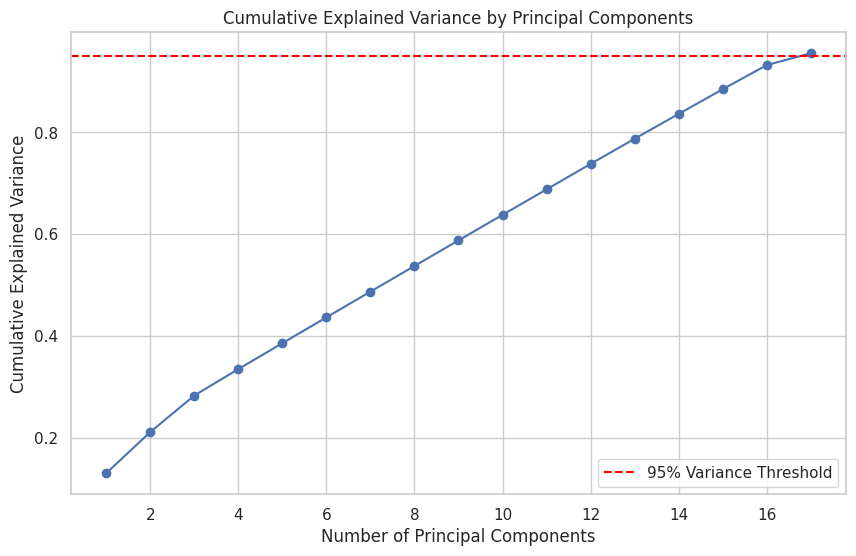

In [48]:
# =============================================================================
# 3.6.3 Plot Cumulative Explained Variance
# =============================================================================

# Plot cumulative explained variance
plt.figure(figsize=(10, 6))
plt.plot(
    range(1, len(cumulative_variance) + 1),
    cumulative_variance,
    marker="o"
)
plt.axhline(y=0.95, color="red", linestyle="--", label="95% Variance Threshold")
plt.title("Cumulative Explained Variance by Principal Components")
plt.xlabel("Number of Principal Components")
plt.ylabel("Cumulative Explained Variance")
plt.legend()
plt.grid(True)
plt.show()

##**Step 4: Model Implementation and Comparison**
####Implement, compare, and optimize multiple fraud-detection models to identify the strongest final candidate for deployment.
####📑 **Full Discussion:** *Full narrative discussion is provided in the accompanying Capstone Report.*

###**4.1. Modeling Strategy and Experimental Design**

In [49]:
# =============================================================================
# 4.1.1 Load Step 4 libraries and define evaluation utilities
# =============================================================================

import os
import json
import joblib
import warnings
import subprocess
import sys

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.base import clone
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.utils.class_weight import compute_sample_weight
from sklearn.model_selection import RandomizedSearchCV, StratifiedKFold
from sklearn.metrics import (
    roc_auc_score,
    precision_recall_curve,
    auc,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix,
    make_scorer
)

warnings.filterwarnings("ignore")

# Define consistent metric names
METRIC_COLUMNS = [
    "Recall_Fraud",
    "Precision_Fraud",
    "F1_Fraud",
    "ROC_AUC",
    "PR_AUC"
]

# Define consistent dataset labels and order
DATASET_ORDER = {
    "Selected Features": 0,
    "Full Features": 1,
    "PCA Features": 2
}

DATASET_LABELS = ["Selected Features", "Full Features", "PCA Features"]

def evaluate_classifier(
    model,
    X_train,
    X_test,
    y_train,
    y_test,
    model_name,
    feature_set_name
):
    # Fit model
    fitted_model = clone(model)
    fitted_model.fit(X_train, y_train)

    # Generate predictions
    y_pred = fitted_model.predict(X_test)
    y_score = fitted_model.predict_proba(X_test)[:, 1]

    # Compute ranking metrics
    roc_auc = roc_auc_score(y_test, y_score)
    precision_curve, recall_curve, _ = precision_recall_curve(y_test, y_score)
    pr_auc = auc(recall_curve, precision_curve)

    # Compute fraud-class metrics
    precision_fraud = precision_score(y_test, y_pred, pos_label=1, zero_division=0)
    recall_fraud = recall_score(y_test, y_pred, pos_label=1, zero_division=0)
    f1_fraud = f1_score(y_test, y_pred, pos_label=1, zero_division=0)

    # Print model diagnostics
    print(f"\nModel: {model_name} | Feature Set: {feature_set_name}")
    print("-" * 70)
    print(f"ROC-AUC: {roc_auc:.4f}")
    print(f"PR-AUC:  {pr_auc:.4f}")
    print("\nClassification Report:")
    print(classification_report(y_test, y_pred, digits=4, zero_division=0))
    print("Confusion Matrix:")
    print(confusion_matrix(y_test, y_pred))

    # Return metrics and fitted model
    return {
        "Model": model_name,
        "Feature_Set": feature_set_name,
        "Recall_Fraud": recall_fraud,
        "Precision_Fraud": precision_fraud,
        "F1_Fraud": f1_fraud,
        "ROC_AUC": roc_auc,
        "PR_AUC": pr_auc,
        "Fitted_Model": fitted_model
    }

def evaluate_classifier_with_sample_weight(
    model,
    X_train,
    X_test,
    y_train,
    y_test,
    model_name,
    feature_set_name,
    sample_weight_train
):
    # Fit model with sample weights
    fitted_model = clone(model)
    fitted_model.fit(X_train, y_train, sample_weight=sample_weight_train)

    # Generate predictions
    y_pred = fitted_model.predict(X_test)
    y_score = fitted_model.predict_proba(X_test)[:, 1]

    # Compute ranking metrics
    roc_auc = roc_auc_score(y_test, y_score)
    precision_curve, recall_curve, _ = precision_recall_curve(y_test, y_score)
    pr_auc = auc(recall_curve, precision_curve)

    # Compute fraud-class metrics
    precision_fraud = precision_score(y_test, y_pred, pos_label=1, zero_division=0)
    recall_fraud = recall_score(y_test, y_pred, pos_label=1, zero_division=0)
    f1_fraud = f1_score(y_test, y_pred, pos_label=1, zero_division=0)

    # Print model diagnostics
    print(f"\nModel: {model_name} | Feature Set: {feature_set_name}")
    print("-" * 70)
    print(f"ROC-AUC: {roc_auc:.4f}")
    print(f"PR-AUC:  {pr_auc:.4f}")
    print("\nClassification Report:")
    print(classification_report(y_test, y_pred, digits=4, zero_division=0))
    print("Confusion Matrix:")
    print(confusion_matrix(y_test, y_pred))

    # Return metrics and fitted model
    return {
        "Model": model_name,
        "Feature_Set": feature_set_name,
        "Recall_Fraud": recall_fraud,
        "Precision_Fraud": precision_fraud,
        "F1_Fraud": f1_fraud,
        "ROC_AUC": roc_auc,
        "PR_AUC": pr_auc,
        "Fitted_Model": fitted_model
    }

def build_results_table(result_dicts):
    # Convert result dictionaries to a comparison table
    cleaned_results = [
        {k: v for k, v in result.items() if k != "Fitted_Model"}
        for result in result_dicts
    ]

    results_df = pd.DataFrame(cleaned_results)
    results_df["Dataset_Type"] = results_df["Feature_Set"].map(DATASET_ORDER)

    results_df = (
        results_df[
            ["Dataset_Type", "Model", "Feature_Set"] + METRIC_COLUMNS
        ]
        .sort_values(by=["Dataset_Type", "Model"])
        .reset_index(drop=True)
        .round(4)
    )

    return results_df

def plot_metric_comparison(comparison_df, title):
    # Reshape comparison data for plotting
    comparison_long_df = comparison_df.melt(
        id_vars=["Dataset_Type", "Model", "Feature_Set"],
        value_vars=["PR_AUC", "Recall_Fraud", "Precision_Fraud", "F1_Fraud", "ROC_AUC"],
        var_name="Metric",
        value_name="Score"
    )

    # Plot grouped bar chart
    plt.figure(figsize=(14, 7))
    sns.barplot(
        data=comparison_long_df,
        x="Metric",
        y="Score",
        hue="Model"
    )
    plt.title(title)
    plt.xlabel("Evaluation Metric")
    plt.ylabel("Score")
    plt.ylim(0, 1.05)
    plt.legend(
        title="Model",
        bbox_to_anchor=(0.5, -0.25),
        loc="upper center",
        ncol=3
    )
    plt.tight_layout()
    plt.show()

In [50]:
# =============================================================================
# 4.1.2 Define modeling datasets
# =============================================================================

# Define train-test datasets for each feature representation
modeling_datasets = {
    "Selected Features": {
        "X_train": X_train_selected,
        "X_test": X_test_selected
    },
    "Full Features": {
        "X_train": X_train_scaled,
        "X_test": X_test_scaled
    },
    "PCA Features": {
        "X_train": X_train_pca,
        "X_test": X_test_pca
    }
}

# Display dataset shapes
dataset_shape_summary = pd.DataFrame({
    "Feature_Set": list(modeling_datasets.keys()),
    "Train_Shape": [modeling_datasets[name]["X_train"].shape for name in modeling_datasets],
    "Test_Shape": [modeling_datasets[name]["X_test"].shape for name in modeling_datasets]
})

dataset_shape_summary

,Feature_Set,Train_Shape,Test_Shape
0,Selected Features,"(226980, 20)","(56746, 20)"
1,Full Features,"(226980, 36)","(56746, 36)"
2,PCA Features,"(226980, 17)","(56746, 17)"


In [51]:
# =============================================================================
# 4.1.3 Define evaluation framework and comparison metrics
# =============================================================================

# Define evaluation framework summary
evaluation_framework_df = pd.DataFrame({
    "Metric": ["Recall_Fraud", "Precision_Fraud", "F1_Fraud", "ROC_AUC", "PR_AUC"],
    "Use_in_Step_4": [
        "Detect fraud capture performance",
        "Assess false-positive burden",
        "Balance recall and precision",
        "Compare overall class discrimination",
        "Rank models under class imbalance"
    ]
})

evaluation_framework_df

,Metric,Use_in_Step_4
0,Recall_Fraud,Detect fraud capture performance
1,Precision_Fraud,Assess false-positive burden
2,F1_Fraud,Balance recall and precision
3,ROC_AUC,Compare overall class discrimination
4,PR_AUC,Rank models under class imbalance


In [53]:
# =============================================================================
# 4.1.4 Define imbalance-handling logic by algorithm
# =============================================================================

# Compute sample weights for Gradient Boosting
sample_weights_train = compute_sample_weight(
    class_weight="balanced",
    y=y_train
)

# Compute scale_pos_weight for XGBoost
scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum()

# Summarize imbalance-handling logic
imbalance_logic_df = pd.DataFrame({
    "Algorithm": [
        "Logistic Regression",
        "Decision Tree",
        "Random Forest",
        "Gradient Boosting",
        "XGBoost"
    ],
    "Imbalance_Handling": [
        "class_weight='balanced'",
        "class_weight='balanced'",
        "class_weight='balanced'",
        "sample_weight from y_train",
        "scale_pos_weight from y_train"
    ]
})

imbalance_logic_df

,Algorithm,Imbalance_Handling
0,Logistic Regression,class_weight='balanced'
1,Decision Tree,class_weight='balanced'
2,Random Forest,class_weight='balanced'
3,Gradient Boosting,sample_weight from y_train
4,XGBoost,scale_pos_weight from y_train


###**4.2. Baseline Model Implementation**

In [55]:
# =============================================================================
# 4.2.1 Implement Logistic Regression model
# =============================================================================

# Initialize baseline model
lr_baseline = LogisticRegression(
    class_weight="balanced",
    max_iter=1000,
    random_state=RANDOM_STATE
)

print("Baseline Logistic Regression initialized successfully.")
print(lr_baseline)

# Evaluate baseline model across feature sets
lr_results = []

for feature_set_name, dataset_bundle in modeling_datasets.items():
    result = evaluate_classifier(
        model=lr_baseline,
        X_train=dataset_bundle["X_train"],
        X_test=dataset_bundle["X_test"],
        y_train=y_train,
        y_test=y_test,
        model_name="Logistic Regression",
        feature_set_name=feature_set_name
    )
    lr_results.append(result)

# Build baseline results table
lr_baseline_results_df = build_results_table(lr_results)
lr_baseline_results_df

Baseline Logistic Regression initialized successfully.
LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42)

Model: Logistic Regression | Feature Set: Selected Features
----------------------------------------------------------------------
ROC-AUC: 0.9714
PR-AUC:  0.6609

Classification Report:
              precision    recall  f1-score   support

           0     0.9998    0.9766    0.9881     56651
           1     0.0590    0.8737    0.1105        95

    accuracy                         0.9765     56746
   macro avg     0.5294    0.9252    0.5493     56746
weighted avg     0.9982    0.9765    0.9866     56746

Confusion Matrix:
[[55327  1324]
 [   12    83]]

Model: Logistic Regression | Feature Set: Full Features
----------------------------------------------------------------------
ROC-AUC: 0.9697
PR-AUC:  0.7109

Classification Report:
              precision    recall  f1-score   support

           0     0.9998    0.9751    0.9873     56651
           1

,Dataset_Type,Model,Feature_Set,Recall_Fraud,Precision_Fraud,F1_Fraud,ROC_AUC,PR_AUC
0,0,Logistic Regression,Selected Features,0.8737,0.0590,0.1105,0.9714,0.6609
1,1,Logistic Regression,Full Features,0.8737,0.0556,0.1046,0.9697,0.7109
2,2,Logistic Regression,PCA Features,0.8737,0.0601,0.1125,0.9671,0.6444


In [56]:
# =============================================================================
# 4.2.2 Save baseline results
# =============================================================================

# Create output folder
os.makedirs("results", exist_ok=True)

# Save baseline results
lr_baseline_results_df.to_csv(
    "results/step4_2_logistic_regression_results.csv",
    index=False
)

print("Baseline Logistic Regression results saved successfully.")

Baseline Logistic Regression results saved successfully.


###**4.3. Advanced Model Implementation**

In [57]:
# =============================================================================
# 4.3.1 Implement Decision Tree model
# =============================================================================

# Initialize Decision Tree model
dt_model = DecisionTreeClassifier(
    class_weight="balanced",
    max_depth=8,
    random_state=RANDOM_STATE
)

print("Decision Tree initialized successfully.")
print(dt_model)

# Evaluate Decision Tree across feature sets
dt_results = []

for feature_set_name, dataset_bundle in modeling_datasets.items():
    result = evaluate_classifier(
        model=dt_model,
        X_train=dataset_bundle["X_train"],
        X_test=dataset_bundle["X_test"],
        y_train=y_train,
        y_test=y_test,
        model_name="Decision Tree",
        feature_set_name=feature_set_name
    )
    dt_results.append(result)

# Summarize Decision Tree results
dt_results_df = build_results_table(dt_results)
dt_results_df

Decision Tree initialized successfully.
DecisionTreeClassifier(class_weight='balanced', max_depth=8, random_state=42)

Model: Decision Tree | Feature Set: Selected Features
----------------------------------------------------------------------
ROC-AUC: 0.9012
PR-AUC:  0.2668

Classification Report:
              precision    recall  f1-score   support

           0     0.9997    0.9938    0.9967     56651
           1     0.1776    0.8000    0.2906        95

    accuracy                         0.9935     56746
   macro avg     0.5886    0.8969    0.6437     56746
weighted avg     0.9983    0.9935    0.9955     56746

Confusion Matrix:
[[56299   352]
 [   19    76]]

Model: Decision Tree | Feature Set: Full Features
----------------------------------------------------------------------
ROC-AUC: 0.9074
PR-AUC:  0.2677

Classification Report:
              precision    recall  f1-score   support

           0     0.9997    0.9917    0.9956     56651
           1     0.1384    0.8000    

,Dataset_Type,Model,Feature_Set,Recall_Fraud,Precision_Fraud,F1_Fraud,ROC_AUC,PR_AUC
0,0,Decision Tree,Selected Features,0.8000,0.1776,0.2906,0.9012,0.2668
1,1,Decision Tree,Full Features,0.8000,0.1384,0.2360,0.9074,0.2677
2,2,Decision Tree,PCA Features,0.8000,0.0582,0.1086,0.8954,0.3417


####**4.3.2. Random Forest**

In [58]:
# =============================================================================
# 4.3.2 Implement Random Forest model
# =============================================================================

# Initialize Random Forest model
rf_model = RandomForestClassifier(
    n_estimators=200,
    max_depth=12,
    class_weight="balanced",
    random_state=RANDOM_STATE,
    n_jobs=-1
)

print("Random Forest initialized successfully.")
print(rf_model)

# Evaluate Random Forest across feature sets
rf_results = []

for feature_set_name, dataset_bundle in modeling_datasets.items():
    result = evaluate_classifier(
        model=rf_model,
        X_train=dataset_bundle["X_train"],
        X_test=dataset_bundle["X_test"],
        y_train=y_train,
        y_test=y_test,
        model_name="Random Forest",
        feature_set_name=feature_set_name
    )
    rf_results.append(result)

# Summarize Random Forest results
rf_results_df = build_results_table(rf_results)
rf_results_df

Random Forest initialized successfully.
RandomForestClassifier(class_weight='balanced', max_depth=12, n_estimators=200,
                       n_jobs=-1, random_state=42)

Model: Random Forest | Feature Set: Selected Features
----------------------------------------------------------------------
ROC-AUC: 0.9642
PR-AUC:  0.7940

Classification Report:
              precision    recall  f1-score   support

           0     0.9996    0.9998    0.9997     56651
           1     0.8861    0.7368    0.8046        95

    accuracy                         0.9994     56746
   macro avg     0.9428    0.8683    0.9021     56746
weighted avg     0.9994    0.9994    0.9994     56746

Confusion Matrix:
[[56642     9]
 [   25    70]]

Model: Random Forest | Feature Set: Full Features
----------------------------------------------------------------------
ROC-AUC: 0.9802
PR-AUC:  0.7907

Classification Report:
              precision    recall  f1-score   support

           0     0.9996    0.9998    0

,Dataset_Type,Model,Feature_Set,Recall_Fraud,Precision_Fraud,F1_Fraud,ROC_AUC,PR_AUC
0,0,Random Forest,Selected Features,0.7368,0.8861,0.8046,0.9642,0.7940
1,1,Random Forest,Full Features,0.7368,0.8861,0.8046,0.9802,0.7907
2,2,Random Forest,PCA Features,0.7368,0.8537,0.7910,0.9531,0.7960


In [59]:
# =============================================================================
# 4.3.3 Implement Gradient Boosting model
# =============================================================================

# Initialize Gradient Boosting model
gb_model = GradientBoostingClassifier(
    n_estimators=150,
    learning_rate=0.05,
    max_depth=3,
    random_state=RANDOM_STATE
)

print("Gradient Boosting initialized successfully.")
print(gb_model)
print("\nSample weights computed successfully.")
print("Number of training observations:", len(sample_weights_train))

# Evaluate Gradient Boosting across feature sets
gb_results = []

for feature_set_name, dataset_bundle in modeling_datasets.items():
    result = evaluate_classifier_with_sample_weight(
        model=gb_model,
        X_train=dataset_bundle["X_train"],
        X_test=dataset_bundle["X_test"],
        y_train=y_train,
        y_test=y_test,
        model_name="Gradient Boosting",
        feature_set_name=feature_set_name,
        sample_weight_train=sample_weights_train
    )
    gb_results.append(result)

# Summarize Gradient Boosting results
gb_results_df = build_results_table(gb_results)
gb_results_df

Gradient Boosting initialized successfully.
GradientBoostingClassifier(learning_rate=0.05, n_estimators=150,
                           random_state=42)

Sample weights computed successfully.
Number of training observations: 226980

Model: Gradient Boosting | Feature Set: Selected Features
----------------------------------------------------------------------
ROC-AUC: 0.9752
PR-AUC:  0.7276

Classification Report:
              precision    recall  f1-score   support

           0     0.9997    0.9911    0.9954     56651
           1     0.1368    0.8421    0.2353        95

    accuracy                         0.9908     56746
   macro avg     0.5682    0.9166    0.6153     56746
weighted avg     0.9983    0.9908    0.9941     56746

Confusion Matrix:
[[56146   505]
 [   15    80]]

Model: Gradient Boosting | Feature Set: Full Features
----------------------------------------------------------------------
ROC-AUC: 0.9754
PR-AUC:  0.7150

Classification Report:
              precision 

,Dataset_Type,Model,Feature_Set,Recall_Fraud,Precision_Fraud,F1_Fraud,ROC_AUC,PR_AUC
0,0,Gradient Boosting,Selected Features,0.8421,0.1368,0.2353,0.9752,0.7276
1,1,Gradient Boosting,Full Features,0.8316,0.1411,0.2412,0.9754,0.7150
2,2,Gradient Boosting,PCA Features,0.8421,0.1311,0.2270,0.9501,0.6343


In [60]:
# =============================================================================
# 4.3.4 Implement XGBoost model
# =============================================================================

# Install XGBoost if missing
try:
    from xgboost import XGBClassifier
except ImportError:
    subprocess.check_call([sys.executable, "-m", "pip", "install", "xgboost"])
    from xgboost import XGBClassifier

# Initialize XGBoost model
xgb_model = XGBClassifier(
    n_estimators=200,
    learning_rate=0.05,
    max_depth=4,
    subsample=0.8,
    colsample_bytree=0.8,
    scale_pos_weight=scale_pos_weight,
    objective="binary:logistic",
    eval_metric="logloss",
    random_state=RANDOM_STATE,
    n_jobs=-1
)

print("XGBoost initialized successfully.")
print(xgb_model)
print("\nscale_pos_weight:", round(scale_pos_weight, 4))

# Evaluate XGBoost across feature sets
xgb_results = []

for feature_set_name, dataset_bundle in modeling_datasets.items():
    result = evaluate_classifier(
        model=xgb_model,
        X_train=dataset_bundle["X_train"],
        X_test=dataset_bundle["X_test"],
        y_train=y_train,
        y_test=y_test,
        model_name="XGBoost",
        feature_set_name=feature_set_name
    )
    xgb_results.append(result)

# Summarize XGBoost results
xgb_results_df = build_results_table(xgb_results)
xgb_results_df

XGBoost initialized successfully.
XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=0.8, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='logloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.05, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=4, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=200, n_jobs=-1,
              num_parallel_tree=None, ...)

scale_pos_weight: 599.4762

Model: XGBoost | Feature Set: Selected Features
----------------------------------------------------------------------
ROC-AUC: 0.9786
PR-AUC:  0.7608

Classificati

,Dataset_Type,Model,Feature_Set,Recall_Fraud,Precision_Fraud,F1_Fraud,ROC_AUC,PR_AUC
0,0,XGBoost,Selected Features,0.8211,0.3768,0.5166,0.9786,0.7608
1,1,XGBoost,Full Features,0.8316,0.4647,0.5962,0.9762,0.7827
2,2,XGBoost,PCA Features,0.8211,0.2889,0.4274,0.9568,0.6981


In [62]:
# =============================================================================
# 4.3.5 Consolidate advanced model results
# =============================================================================

# Combine advanced model results
advanced_model_results_df = pd.concat(
    [dt_results_df, rf_results_df, gb_results_df, xgb_results_df],
    ignore_index=True
)

advanced_model_results_df = (
    advanced_model_results_df
    .sort_values(by=["Dataset_Type", "Model"])
    .reset_index(drop=True)
    .round(4)
)

display(advanced_model_results_df)

# Save advanced model results
advanced_model_results_df.to_csv(
    "results/step4_3_advanced_model_results.csv",
    index=False
)

print("Advanced model results saved successfully.")

,Dataset_Type,Model,Feature_Set,Recall_Fraud,Precision_Fraud,F1_Fraud,ROC_AUC,PR_AUC
0,0,Decision Tree,Selected Features,0.8000,0.1776,0.2906,0.9012,0.2668
1,0,Gradient Boosting,Selected Features,0.8421,0.1368,0.2353,0.9752,0.7276
2,0,Random Forest,Selected Features,0.7368,0.8861,0.8046,0.9642,0.7940
3,0,XGBoost,Selected Features,0.8211,0.3768,0.5166,0.9786,0.7608
4,1,Decision Tree,Full Features,0.8000,0.1384,0.2360,0.9074,0.2677
5,1,Gradient Boosting,Full Features,0.8316,0.1411,0.2412,0.9754,0.7150
6,1,Random Forest,Full Features,0.7368,0.8861,0.8046,0.9802,0.7907
7,1,XGBoost,Full Features,0.8316,0.4647,0.5962,0.9762,0.7827
8,2,Decision Tree,PCA Features,0.8000,0.0582,0.1086,0.8954,0.3417
9,2,Gradient Boosting,PCA Features,0.8421,0.1311,0.2270,0.9501,0.6343


Advanced model results saved successfully.


###**4.4. Model Comparison**

In [63]:
# =============================================================================
# 4.4.1 Combine baseline and advanced model results
# =============================================================================

# Combine all model results
all_model_results_df = pd.concat(
    [lr_baseline_results_df, advanced_model_results_df],
    ignore_index=True
).round(4)

print("Number of model-dataset combinations:", len(all_model_results_df))
display(all_model_results_df)

Number of model-dataset combinations: 15


,Dataset_Type,Model,Feature_Set,Recall_Fraud,Precision_Fraud,F1_Fraud,ROC_AUC,PR_AUC
0,0,Logistic Regression,Selected Features,0.8737,0.0590,0.1105,0.9714,0.6609
1,1,Logistic Regression,Full Features,0.8737,0.0556,0.1046,0.9697,0.7109
2,2,Logistic Regression,PCA Features,0.8737,0.0601,0.1125,0.9671,0.6444
3,0,Decision Tree,Selected Features,0.8000,0.1776,0.2906,0.9012,0.2668
4,0,Gradient Boosting,Selected Features,0.8421,0.1368,0.2353,0.9752,0.7276
5,0,Random Forest,Selected Features,0.7368,0.8861,0.8046,0.9642,0.7940
6,0,XGBoost,Selected Features,0.8211,0.3768,0.5166,0.9786,0.7608
7,1,Decision Tree,Full Features,0.8000,0.1384,0.2360,0.9074,0.2677
8,1,Gradient Boosting,Full Features,0.8316,0.1411,0.2412,0.9754,0.7150
9,1,Random Forest,Full Features,0.7368,0.8861,0.8046,0.9802,0.7907


In [69]:
# =============================================================================
# 4.4.2 Rank model-dataset combinations
# =============================================================================

# Rank all model-dataset combinations
ranked_model_results_df = (
    all_model_results_df
    .sort_values(by=["PR_AUC", "Recall_Fraud", "F1_Fraud"], ascending=False)
    .reset_index(drop=True)
    .round(4)
)

print('Ranked model results')
display(ranked_model_results_df)

# Display top overall combinations
top_overall_models_df = ranked_model_results_df.head(10).copy()
print('\nTop overall combinations')
display(top_overall_models_df)

# Identify best model within each dataset type
best_model_per_dataset_df = (
    all_model_results_df
    .sort_values(
        by=["Dataset_Type", "PR_AUC", "Recall_Fraud", "F1_Fraud"],
        ascending=[True, False, False, False]
    )
    .groupby("Dataset_Type", as_index=False)
    .head(1)
    .reset_index(drop=True)
    .round(4)
)

print('\nBest model per dataset')
display(best_model_per_dataset_df)

# Identify best dataset representation within each model
best_dataset_per_model_df = (
    all_model_results_df
    .sort_values(
        by=["Model", "PR_AUC", "Recall_Fraud", "F1_Fraud"],
        ascending=[True, False, False, False]
    )
    .groupby("Model", as_index=False)
    .head(1)
    .reset_index(drop=True)
    .round(4)
)

print('\nBest dataset per model')
display(best_dataset_per_model_df)

Ranked model results


,Dataset_Type,Model,Feature_Set,Recall_Fraud,Precision_Fraud,F1_Fraud,ROC_AUC,PR_AUC
0,2,Random Forest,PCA Features,0.7368,0.8537,0.7910,0.9531,0.7960
1,0,Random Forest,Selected Features,0.7368,0.8861,0.8046,0.9642,0.7940
2,1,Random Forest,Full Features,0.7368,0.8861,0.8046,0.9802,0.7907
3,1,XGBoost,Full Features,0.8316,0.4647,0.5962,0.9762,0.7827
4,0,XGBoost,Selected Features,0.8211,0.3768,0.5166,0.9786,0.7608
5,0,Gradient Boosting,Selected Features,0.8421,0.1368,0.2353,0.9752,0.7276
6,1,Gradient Boosting,Full Features,0.8316,0.1411,0.2412,0.9754,0.7150
7,1,Logistic Regression,Full Features,0.8737,0.0556,0.1046,0.9697,0.7109
8,2,XGBoost,PCA Features,0.8211,0.2889,0.4274,0.9568,0.6981
9,0,Logistic Regression,Selected Features,0.8737,0.0590,0.1105,0.9714,0.6609



Top overall combinations


,Dataset_Type,Model,Feature_Set,Recall_Fraud,Precision_Fraud,F1_Fraud,ROC_AUC,PR_AUC
0,2,Random Forest,PCA Features,0.7368,0.8537,0.7910,0.9531,0.7960
1,0,Random Forest,Selected Features,0.7368,0.8861,0.8046,0.9642,0.7940
2,1,Random Forest,Full Features,0.7368,0.8861,0.8046,0.9802,0.7907
3,1,XGBoost,Full Features,0.8316,0.4647,0.5962,0.9762,0.7827
4,0,XGBoost,Selected Features,0.8211,0.3768,0.5166,0.9786,0.7608
5,0,Gradient Boosting,Selected Features,0.8421,0.1368,0.2353,0.9752,0.7276
6,1,Gradient Boosting,Full Features,0.8316,0.1411,0.2412,0.9754,0.7150
7,1,Logistic Regression,Full Features,0.8737,0.0556,0.1046,0.9697,0.7109
8,2,XGBoost,PCA Features,0.8211,0.2889,0.4274,0.9568,0.6981
9,0,Logistic Regression,Selected Features,0.8737,0.0590,0.1105,0.9714,0.6609



Best model per dataset


,Dataset_Type,Model,Feature_Set,Recall_Fraud,Precision_Fraud,F1_Fraud,ROC_AUC,PR_AUC
0,0,Random Forest,Selected Features,0.7368,0.8861,0.8046,0.9642,0.7940
1,1,Random Forest,Full Features,0.7368,0.8861,0.8046,0.9802,0.7907
2,2,Random Forest,PCA Features,0.7368,0.8537,0.7910,0.9531,0.7960



Best dataset per model


,Dataset_Type,Model,Feature_Set,Recall_Fraud,Precision_Fraud,F1_Fraud,ROC_AUC,PR_AUC
0,2,Decision Tree,PCA Features,0.8000,0.0582,0.1086,0.8954,0.3417
1,0,Gradient Boosting,Selected Features,0.8421,0.1368,0.2353,0.9752,0.7276
2,1,Logistic Regression,Full Features,0.8737,0.0556,0.1046,0.9697,0.7109
3,2,Random Forest,PCA Features,0.7368,0.8537,0.7910,0.9531,0.7960
4,1,XGBoost,Full Features,0.8316,0.4647,0.5962,0.9762,0.7827


Comparison by dataset


,Dataset_Type,Model,Feature_Set,Recall_Fraud,Precision_Fraud,F1_Fraud,ROC_AUC,PR_AUC
0,0,Random Forest,Selected Features,0.7368,0.8861,0.8046,0.9642,0.7940
1,0,XGBoost,Selected Features,0.8211,0.3768,0.5166,0.9786,0.7608
2,0,Gradient Boosting,Selected Features,0.8421,0.1368,0.2353,0.9752,0.7276
3,0,Logistic Regression,Selected Features,0.8737,0.0590,0.1105,0.9714,0.6609
4,0,Decision Tree,Selected Features,0.8000,0.1776,0.2906,0.9012,0.2668
5,1,Random Forest,Full Features,0.7368,0.8861,0.8046,0.9802,0.7907
6,1,XGBoost,Full Features,0.8316,0.4647,0.5962,0.9762,0.7827
7,1,Gradient Boosting,Full Features,0.8316,0.1411,0.2412,0.9754,0.7150
8,1,Logistic Regression,Full Features,0.8737,0.0556,0.1046,0.9697,0.7109
9,1,Decision Tree,Full Features,0.8000,0.1384,0.2360,0.9074,0.2677


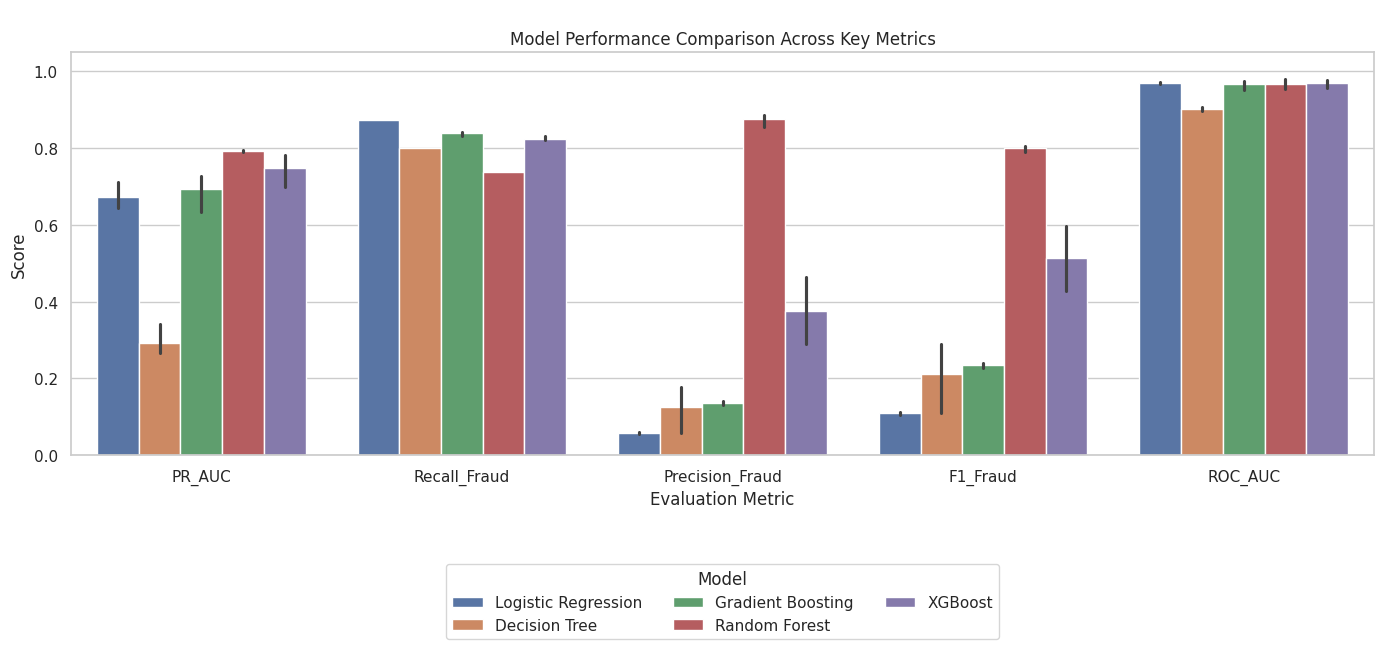

In [71]:
# =============================================================================
# 4.4.6 Visualize model comparisons
# =============================================================================

# Create dataset-sorted comparison table
comparison_by_dataset_df = (
    all_model_results_df
    .sort_values(
        by=["Dataset_Type", "PR_AUC", "Recall_Fraud", "F1_Fraud"],
        ascending=[True, False, False, False]
    )
    .reset_index(drop=True)
    .round(4)
)

print('Comparison by dataset')
display(comparison_by_dataset_df)

# Plot model comparison
plot_metric_comparison(
    comparison_df=all_model_results_df,
    title="\nModel Performance Comparison Across Key Metrics"
)

###**4.5. Hyperparametric Tuning**
####**Selected models:**
####🔹 XGBoost - Full Features
####🔹  Random Forest - Full Features
####🔹  Random Forest - PCA Features

In [72]:
# =============================================================================
# 4.5.1 Define tuning setup, scorer, and cross-validation strategy
# =============================================================================

# Define fraud-focused scorer
f1_scorer = make_scorer(f1_score, pos_label=1)

# Define stratified cross-validation strategy
cv_strategy = StratifiedKFold(
    n_splits=3,
    shuffle=True,
    random_state=RANDOM_STATE
)

print("Hyperparameter tuning setup complete.")
print("Scoring metric: F1 (fraud class)")
print("Cross-validation strategy:", cv_strategy)

Hyperparameter tuning setup complete.
Scoring metric: F1 (fraud class)
Cross-validation strategy: StratifiedKFold(n_splits=3, random_state=42, shuffle=True)


In [73]:
# =============================================================================
# 4.5.2 Tune XGBoost – Full Features
# =============================================================================

# Define XGBoost search space
xgb_param_dist = {
    "n_estimators": [100, 200, 300],
    "max_depth": [3, 4, 5],
    "learning_rate": [0.01, 0.05, 0.1],
    "subsample": [0.7, 0.8, 0.9],
    "colsample_bytree": [0.7, 0.8, 0.9]
}

# Run randomized search
xgb_tuned = RandomizedSearchCV(
    estimator=XGBClassifier(
        scale_pos_weight=scale_pos_weight,
        objective="binary:logistic",
        eval_metric="logloss",
        random_state=RANDOM_STATE,
        n_jobs=-1
    ),
    param_distributions=xgb_param_dist,
    n_iter=10,
    scoring=f1_scorer,
    cv=cv_strategy,
    verbose=1,
    random_state=RANDOM_STATE,
    n_jobs=-1
)

xgb_tuned.fit(X_train_scaled, y_train)

print("Best XGBoost Params:")
print(xgb_tuned.best_params_)

# Evaluate tuned XGBoost
xgb_best_model = xgb_tuned.best_estimator_

xgb_tuned_result = evaluate_classifier(
    model=xgb_best_model,
    X_train=X_train_scaled,
    X_test=X_test_scaled,
    y_train=y_train,
    y_test=y_test,
    model_name="XGBoost Tuned",
    feature_set_name="Full Features"
)

xgb_tuned_results_df = build_results_table([xgb_tuned_result])
xgb_tuned_results_df

Fitting 3 folds for each of 10 candidates, totalling 30 fits
Best XGBoost Params:
{'subsample': 0.8, 'n_estimators': 300, 'max_depth': 4, 'learning_rate': 0.1, 'colsample_bytree': 0.9}

Model: XGBoost Tuned | Feature Set: Full Features
----------------------------------------------------------------------
ROC-AUC: 0.9718
PR-AUC:  0.8162

Classification Report:
              precision    recall  f1-score   support

           0     0.9997    0.9999    0.9998     56651
           1     0.9048    0.8000    0.8492        95

    accuracy                         0.9995     56746
   macro avg     0.9522    0.8999    0.9245     56746
weighted avg     0.9995    0.9995    0.9995     56746

Confusion Matrix:
[[56643     8]
 [   19    76]]


,Dataset_Type,Model,Feature_Set,Recall_Fraud,Precision_Fraud,F1_Fraud,ROC_AUC,PR_AUC
0,1,XGBoost Tuned,Full Features,0.8000,0.9048,0.8492,0.9718,0.8162


In [74]:
# =============================================================================
# 4.5.3 Tune Random Forest – Full Features
# =============================================================================

# Define Random Forest search space
rf_param_dist = {
    "n_estimators": [100, 200, 300],
    "max_depth": [8, 12, 16],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf": [1, 2, 4]
}

# Run randomized search on full features
rf_tuned = RandomizedSearchCV(
    estimator=RandomForestClassifier(
        class_weight="balanced",
        random_state=RANDOM_STATE,
        n_jobs=-1
    ),
    param_distributions=rf_param_dist,
    n_iter=10,
    scoring=f1_scorer,
    cv=cv_strategy,
    verbose=1,
    random_state=RANDOM_STATE,
    n_jobs=-1
)

rf_tuned.fit(X_train_scaled, y_train)

print("Best Random Forest Params:")
print(rf_tuned.best_params_)

# Evaluate tuned Random Forest on full features
rf_best_model = rf_tuned.best_estimator_

rf_tuned_result = evaluate_classifier(
    model=rf_best_model,
    X_train=X_train_scaled,
    X_test=X_test_scaled,
    y_train=y_train,
    y_test=y_test,
    model_name="Random Forest Tuned",
    feature_set_name="Full Features"
)

rf_tuned_results_df = build_results_table([rf_tuned_result])
rf_tuned_results_df

Fitting 3 folds for each of 10 candidates, totalling 30 fits
Best Random Forest Params:
{'n_estimators': 200, 'min_samples_split': 5, 'min_samples_leaf': 4, 'max_depth': 8}

Model: Random Forest Tuned | Feature Set: Full Features
----------------------------------------------------------------------
ROC-AUC: 0.9783
PR-AUC:  0.7708

Classification Report:
              precision    recall  f1-score   support

           0     0.9996    0.9998    0.9997     56651
           1     0.8471    0.7579    0.8000        95

    accuracy                         0.9994     56746
   macro avg     0.9233    0.8788    0.8998     56746
weighted avg     0.9993    0.9994    0.9993     56746

Confusion Matrix:
[[56638    13]
 [   23    72]]


,Dataset_Type,Model,Feature_Set,Recall_Fraud,Precision_Fraud,F1_Fraud,ROC_AUC,PR_AUC
0,1,Random Forest Tuned,Full Features,0.7579,0.8471,0.8000,0.9783,0.7708


In [75]:
# =============================================================================
# Step 4: Model Implementation & Comparison
# 4.5.4 Tune Random Forest – PCA Features
# =============================================================================

# Run randomized search on PCA features
rf_tuned_pca = RandomizedSearchCV(
    estimator=RandomForestClassifier(
        class_weight="balanced",
        random_state=RANDOM_STATE,
        n_jobs=-1
    ),
    param_distributions=rf_param_dist,
    n_iter=10,
    scoring=f1_scorer,
    cv=cv_strategy,
    verbose=1,
    random_state=RANDOM_STATE,
    n_jobs=-1
)

rf_tuned_pca.fit(X_train_pca, y_train)

print("Best Random Forest PCA Params:")
print(rf_tuned_pca.best_params_)

# Evaluate tuned Random Forest on PCA features
rf_best_model_pca = rf_tuned_pca.best_estimator_

rf_tuned_pca_result = evaluate_classifier(
    model=rf_best_model_pca,
    X_train=X_train_pca,
    X_test=X_test_pca,
    y_train=y_train,
    y_test=y_test,
    model_name="Random Forest Tuned",
    feature_set_name="PCA Features"
)

rf_tuned_pca_results_df = build_results_table([rf_tuned_pca_result])
rf_tuned_pca_results_df

Fitting 3 folds for each of 10 candidates, totalling 30 fits
Best Random Forest PCA Params:
{'n_estimators': 100, 'min_samples_split': 5, 'min_samples_leaf': 1, 'max_depth': 12}

Model: Random Forest Tuned | Feature Set: PCA Features
----------------------------------------------------------------------
ROC-AUC: 0.9475
PR-AUC:  0.7945

Classification Report:
              precision    recall  f1-score   support

           0     0.9996    0.9998    0.9997     56651
           1     0.8659    0.7474    0.8023        95

    accuracy                         0.9994     56746
   macro avg     0.9327    0.8736    0.9010     56746
weighted avg     0.9994    0.9994    0.9994     56746

Confusion Matrix:
[[56640    11]
 [   24    71]]


,Dataset_Type,Model,Feature_Set,Recall_Fraud,Precision_Fraud,F1_Fraud,ROC_AUC,PR_AUC
0,2,Random Forest Tuned,PCA Features,0.7474,0.8659,0.8023,0.9475,0.7945


In [76]:
# =============================================================================
# 4.5.5 Consolidate tuned model results
# =============================================================================

# Combine tuned model results
tuned_results_df = build_results_table([
    xgb_tuned_result,
    rf_tuned_result,
    rf_tuned_pca_result
])

print('Tuned model results')
display(tuned_results_df)

# Combine untuned and tuned results
comparison_tuning_df = pd.concat(
    [all_model_results_df, tuned_results_df],
    ignore_index=True
).round(4)

comparison_tuning_df = (
    comparison_tuning_df
    .sort_values(by=["Model", "Dataset_Type"])
    .reset_index(drop=True)
)

print('\nUntuned vs. Tuned Comparison')
display(comparison_tuning_df)

# Summarize tuning improvements
rows = []

for _, tuned_row in tuned_results_df.iterrows():
    tuned_model = tuned_row["Model"]
    feature_set = tuned_row["Feature_Set"]

    if tuned_model == "XGBoost Tuned":
        base_model = "XGBoost"
    elif tuned_model == "Random Forest Tuned":
        base_model = "Random Forest"
    else:
        continue

    untuned_match = all_model_results_df[
        (all_model_results_df["Model"] == base_model) &
        (all_model_results_df["Feature_Set"] == feature_set)
    ]

    if not untuned_match.empty:
        untuned_row = untuned_match.iloc[0]

        for metric_name, metric_column in {
            "F1": "F1_Fraud",
            "Recall": "Recall_Fraud",
            "Precision": "Precision_Fraud",
            "PR-AUC": "PR_AUC"
        }.items():
            before = untuned_row[metric_column]
            after = tuned_row[metric_column]
            change = after - before

            rows.append({
                "Model": tuned_model,
                "Feature_Set": feature_set,
                "Metric": metric_name,
                "Before": round(before, 4),
                "After": round(after, 4),
                "Delta": round(change, 4)
            })

tuning_improvement_df = pd.DataFrame(rows)
print('\nTuning improvements')
display(tuning_improvement_df)

# Save tuning result tables
tuned_results_df.to_csv("results/step4_5_tuned_model_results.csv", index=False)
comparison_tuning_df.to_csv("results/step4_5_untuned_vs_tuned_comparison.csv", index=False)
tuning_improvement_df.to_csv("results/step4_5_tuning_improvement_summary.csv", index=False)

print("Tuning outputs saved successfully.")

Tuned model results


,Dataset_Type,Model,Feature_Set,Recall_Fraud,Precision_Fraud,F1_Fraud,ROC_AUC,PR_AUC
0,1,Random Forest Tuned,Full Features,0.7579,0.8471,0.8000,0.9783,0.7708
1,1,XGBoost Tuned,Full Features,0.8000,0.9048,0.8492,0.9718,0.8162
2,2,Random Forest Tuned,PCA Features,0.7474,0.8659,0.8023,0.9475,0.7945



Untuned vs. Tuned Comparison


,Dataset_Type,Model,Feature_Set,Recall_Fraud,Precision_Fraud,F1_Fraud,ROC_AUC,PR_AUC
0,0,Decision Tree,Selected Features,0.8000,0.1776,0.2906,0.9012,0.2668
1,1,Decision Tree,Full Features,0.8000,0.1384,0.2360,0.9074,0.2677
2,2,Decision Tree,PCA Features,0.8000,0.0582,0.1086,0.8954,0.3417
3,0,Gradient Boosting,Selected Features,0.8421,0.1368,0.2353,0.9752,0.7276
4,1,Gradient Boosting,Full Features,0.8316,0.1411,0.2412,0.9754,0.7150
5,2,Gradient Boosting,PCA Features,0.8421,0.1311,0.2270,0.9501,0.6343
6,0,Logistic Regression,Selected Features,0.8737,0.0590,0.1105,0.9714,0.6609
7,1,Logistic Regression,Full Features,0.8737,0.0556,0.1046,0.9697,0.7109
8,2,Logistic Regression,PCA Features,0.8737,0.0601,0.1125,0.9671,0.6444
9,0,Random Forest,Selected Features,0.7368,0.8861,0.8046,0.9642,0.7940



Tuning improvements


,Model,Feature_Set,Metric,Before,After,Delta
0,Random Forest Tuned,Full Features,F1,0.8046,0.8000,-0.0046
1,Random Forest Tuned,Full Features,Recall,0.7368,0.7579,0.0211
2,Random Forest Tuned,Full Features,Precision,0.8861,0.8471,-0.0390
3,Random Forest Tuned,Full Features,PR-AUC,0.7907,0.7708,-0.0199
4,XGBoost Tuned,Full Features,F1,0.5962,0.8492,0.2530
5,XGBoost Tuned,Full Features,Recall,0.8316,0.8000,-0.0316
6,XGBoost Tuned,Full Features,Precision,0.4647,0.9048,0.4401
7,XGBoost Tuned,Full Features,PR-AUC,0.7827,0.8162,0.0335
8,Random Forest Tuned,PCA Features,F1,0.7910,0.8023,0.0113
9,Random Forest Tuned,PCA Features,Recall,0.7368,0.7474,0.0106


Tuning outputs saved successfully.


###**4.6. Threshold Optimization**
####**Selected model:** Tuned XGBoost - Full Features

In [77]:
# =============================================================================
# 4.6.1 Generate probability scores from final tuned candidate
# =============================================================================

y_scores = xgb_best_model.predict_proba(X_test_scaled)[:, 1]

print("Probability scores generated successfully.")

Probability scores generated successfully.


In [80]:
# =============================================================================
# 4.6.2 Evaluate thresholds across recall, precision, and F1
# =============================================================================

# Evaluate metrics across thresholds
thresholds = np.linspace(0.1, 0.9, 17)
threshold_results = []

for thresh in thresholds:
    y_pred_thresh = (y_scores >= thresh).astype(int)

    precision = precision_score(y_test, y_pred_thresh, zero_division=0)
    recall = recall_score(y_test, y_pred_thresh, zero_division=0)
    f1 = f1_score(y_test, y_pred_thresh, zero_division=0)

    threshold_results.append({
        "Threshold": thresh,
        "Recall_Fraud": recall,
        "Precision_Fraud": precision,
        "F1_Fraud": f1
    })

threshold_df = pd.DataFrame(threshold_results).round(4)
display(threshold_df)

# Select threshold with highest F1
best_threshold_row = threshold_df.sort_values(by="F1_Fraud", ascending=False).iloc[0]
best_threshold = best_threshold_row["Threshold"]

print("\nOptimal Threshold Identified:")
print(best_threshold_row)

,Threshold,Recall_Fraud,Precision_Fraud,F1_Fraud
0,0.1000,0.8105,0.7264,0.7662
1,0.1500,0.8105,0.7700,0.7897
2,0.2000,0.8105,0.7938,0.8021
3,0.2500,0.8105,0.8280,0.8191
4,0.3000,0.8000,0.8539,0.8261
5,0.3500,0.8000,0.8736,0.8352
6,0.4000,0.8000,0.8837,0.8398
7,0.4500,0.8000,0.9048,0.8492
8,0.5000,0.8000,0.9048,0.8492
9,0.5500,0.8000,0.9157,0.8539



Optimal Threshold Identified:
Threshold         0.7500
Recall_Fraud      0.7895
Precision_Fraud   0.9615
F1_Fraud          0.8671
Name: 13, dtype: float64


Classification Report (Optimal Threshold):
              precision    recall  f1-score   support

           0     0.9996    0.9999    0.9998     56651
           1     0.9615    0.7895    0.8671        95

    accuracy                         0.9996     56746
   macro avg     0.9806    0.8947    0.9334     56746
weighted avg     0.9996    0.9996    0.9996     56746

Confusion Matrix:
[[56648     3]
 [   20    75]]


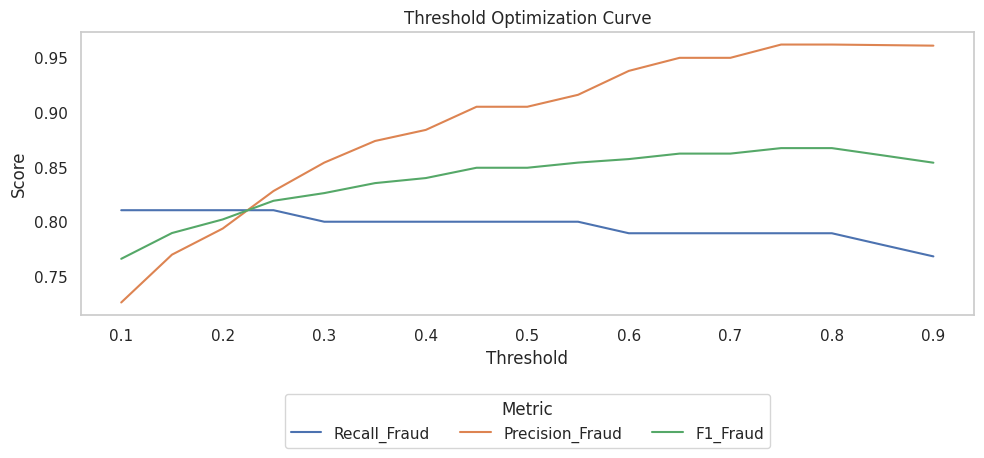

In [81]:
# =============================================================================
# 4.6.3 Evaluate final model at optimal threshold
# =============================================================================

# Generate final predictions at optimal threshold
y_pred_optimal = (y_scores >= best_threshold).astype(int)

print("Classification Report (Optimal Threshold):")
print(classification_report(y_test, y_pred_optimal, digits=4, zero_division=0))

print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred_optimal))

# Plot threshold trade-offs
plt.figure(figsize=(10, 5))
plt.plot(threshold_df["Threshold"], threshold_df["Recall_Fraud"], label="Recall_Fraud")
plt.plot(threshold_df["Threshold"], threshold_df["Precision_Fraud"], label="Precision_Fraud")
plt.plot(threshold_df["Threshold"], threshold_df["F1_Fraud"], label="F1_Fraud")
plt.xlabel("Threshold")
plt.ylabel("Score")
plt.title("Threshold Optimization Curve")
plt.legend(
    title="Metric",
    bbox_to_anchor=(0.5, -0.25),
    loc="upper center",
    ncol=3
)
plt.grid()
plt.tight_layout()
plt.show()

In [82]:
# =============================================================================
# 4.6.4 Save final Step 4 artifacts for reproducibility
# =============================================================================

# Create output folders
os.makedirs("models", exist_ok=True)
os.makedirs("configs", exist_ok=True)
os.makedirs("results", exist_ok=True)

# Save trained model artefacts
joblib.dump(xgb_best_model, "models/final_xgboost_tuned_full_features.pkl")
joblib.dump(rf_best_model, "models/final_random_forest_tuned_full_features.pkl")
joblib.dump(rf_best_model_pca, "models/final_random_forest_tuned_pca_features.pkl")

# Save preprocessing artefacts from Step 3
joblib.dump(scaler, "models/standard_scaler.pkl")
joblib.dump(selector, "models/select_k_best_mutual_info.pkl")
joblib.dump(pca, "models/pca_transformer.pkl")

# Save best hyperparameters
model_params = {
    "xgboost_tuned_full_features": xgb_tuned.best_params_,
    "random_forest_tuned_full_features": rf_tuned.best_params_,
    "random_forest_tuned_pca_features": rf_tuned_pca.best_params_
}

with open("configs/step4_best_params.json", "w") as f:
    json.dump(model_params, f, indent=4)

# Save threshold search results
threshold_df.to_csv("results/step4_6_threshold_optimization.csv", index=False)

print("Final Step 4 artefacts saved successfully.")

Final Step 4 artefacts saved successfully.


###**4.7. Final Model Configuration**
####**Final model:** Tuned XGBoost - Full Features, Threshold = 0.75

In [83]:
final_model_config = {
    "Selected_Final_Model": "XGBoost Tuned",
    "Selected_Feature_Set": "Full Features",
    "Optimization_Metric": "F1_Fraud",
    "Best_Threshold": float(best_threshold),
    "Threshold_Recall_Fraud": float(best_threshold_row["Recall_Fraud"]),
    "Threshold_Precision_Fraud": float(best_threshold_row["Precision_Fraud"]),
    "Threshold_F1_Fraud": float(best_threshold_row["F1_Fraud"])
}

final_model_config_df = pd.DataFrame([final_model_config])
final_model_config_df

,Selected_Final_Model,Selected_Feature_Set,Optimization_Metric,Best_Threshold,Threshold_Recall_Fraud,Threshold_Precision_Fraud,Threshold_F1_Fraud
0,XGBoost Tuned,Full Features,F1_Fraud,0.7500,0.7895,0.9615,0.8671


###**4.8. Reproducibility**

In [84]:
# Save final model artefacts
joblib.dump(xgb_best_model, "models/final_xgboost_tuned_full_features.pkl")
joblib.dump(rf_best_model, "models/final_random_forest_tuned_full_features.pkl")
joblib.dump(rf_best_model_pca, "models/final_random_forest_tuned_pca_features.pkl")

print("Model artefacts saved successfully.")

# Save preprocessing artefacts
joblib.dump(scaler, "models/standard_scaler.pkl")
joblib.dump(selector, "models/select_k_best_mutual_info.pkl")
joblib.dump(pca, "models/pca_transformer.pkl")

print("Preprocessing artefacts saved successfully.")

# Save tuning parameters
with open("configs/step4_best_params.json", "w") as f:
    json.dump(model_params, f, indent=4)

# Save final configuration
with open("configs/final_model_threshold_config.json", "w") as f:
    json.dump(final_model_config, f, indent=4)

print("Parameter and config files saved successfully.")

# Save key result tables
lr_baseline_results_df.to_csv("results/step4_baseline_logistic_results.csv", index=False)
advanced_model_results_df.to_csv("results/step4_advanced_model_results.csv", index=False)
ranked_model_results_df.to_csv("results/step4_ranked_model_results.csv", index=False)
comparison_by_dataset_df.to_csv("results/step4_comparison_by_dataset.csv", index=False)
best_model_per_dataset_df.to_csv("results/step4_best_model_per_dataset.csv", index=False)
best_dataset_per_model_df.to_csv("results/step4_best_dataset_per_model.csv", index=False)
tuned_results_df.to_csv("results/step4_tuned_model_results.csv", index=False)
comparison_tuning_df.to_csv("results/step4_untuned_vs_tuned_comparison.csv", index=False)
tuning_improvement_df.to_csv("results/step4_tuning_improvement_summary.csv", index=False)
threshold_df.to_csv("results/step4_threshold_optimization.csv", index=False)
final_model_config_df.to_csv("results/step4_final_model_configuration.csv", index=False)

print("Result tables and final configuration summary saved successfully.")
print("Saved folders: models/, configs/, results/")

Model artefacts saved successfully.
Preprocessing artefacts saved successfully.
Parameter and config files saved successfully.
Result tables and final configuration summary saved successfully.
Saved folders: models/, configs/, results/


##**Step 5: Critical Thinking, Ethical AI, and Bias Auditing**
####Evaluate the final model critically by examining its explainability, limitations, ethical risks, and subgroup behavior.
####📑 **Full Discussion:** *Full narrative discussion, including Sections 5.5 to 5.8, is provided in the accompanying Capstone Report.*

###**5.1. Baseline Evaluation of Final Model Configuration**

In [85]:
# =============================================================================
# 5.1.1 Initialize evaluation using final model
# =============================================================================

import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    precision_score,
    recall_score,
    f1_score
)

warnings.filterwarnings("ignore")

# Confirm required Step 4 objects
required_objects = {
    "Final Model (xgb_best_model)": "xgb_best_model" in globals(),
    "Scaled Test Features (X_test_scaled)": "X_test_scaled" in globals(),
    "Test Labels (y_test)": "y_test" in globals()
}

required_objects_df = pd.DataFrame(
    list(required_objects.items()),
    columns=["Object", "Available"]
)
display(required_objects_df)

if not all(required_objects.values()):
    raise ValueError("One or more required Step 4 objects are missing.")

# Assign final model and evaluation data
final_model = xgb_best_model
X_eval = X_test_scaled
y_eval = y_test.copy()

# Assign final threshold from Step 4
final_threshold = 0.75

print(f"Final model: {type(final_model).__name__}")
print(f"Evaluation dataset shape: {X_eval.shape}")
print(f"Final threshold: {final_threshold:.2f}")

# Inspect target distribution
target_distribution_df = pd.DataFrame({
    "Class": pd.Series(y_eval).value_counts().index,
    "Count": pd.Series(y_eval).value_counts().values,
    "Proportion": pd.Series(y_eval).value_counts(normalize=True).values
}).round(4)

display(target_distribution_df)

,Object,Available
0,Final Model (xgb_best_model),True
1,Scaled Test Features (X_test_scaled),True
2,Test Labels (y_test),True


Final model: XGBClassifier
Evaluation dataset shape: (56746, 36)
Final threshold: 0.75


,Class,Count,Proportion
0,0,56651,0.9983
1,1,95,0.0017


In [86]:
# =============================================================================
# 5.1.2 Re-evaluate final model at threshold 0.75
# =============================================================================

# Generate probability scores
y_score = final_model.predict_proba(X_eval)[:, 1]

# Apply final threshold
y_pred = (y_score >= final_threshold).astype(int)

print("Predictions generated successfully.")
print(f"Threshold applied: {final_threshold:.2f}")

print("\nClassification Report (Final Model):")
print(classification_report(y_eval, y_pred, digits=4, zero_division=0))

Predictions generated successfully.
Threshold applied: 0.75

Classification Report (Final Model):
              precision    recall  f1-score   support

           0     0.9996    0.9999    0.9998     56651
           1     0.9615    0.7895    0.8671        95

    accuracy                         0.9996     56746
   macro avg     0.9806    0.8947    0.9334     56746
weighted avg     0.9996    0.9996    0.9996     56746



In [87]:
# =============================================================================
# 5.1.3 Build confusion-matrix and fraud-metrics summary
# =============================================================================

# Build confusion matrix table
cm = confusion_matrix(y_eval, y_pred)

cm_df = pd.DataFrame(
    cm,
    index=["Actual 0 (Legit)", "Actual 1 (Fraud)"],
    columns=["Pred 0 (Legit)", "Pred 1 (Fraud)"]
)

print("Confusion Matrix:")
display(cm_df)

# Build fraud-metric summary
fraud_metrics_df = pd.DataFrame({
    "Metric": ["Precision (Fraud)", "Recall (Fraud)", "F1 Score (Fraud)"],
    "Value": [
        precision_score(y_eval, y_pred, pos_label=1, zero_division=0),
        recall_score(y_eval, y_pred, pos_label=1, zero_division=0),
        f1_score(y_eval, y_pred, pos_label=1, zero_division=0)
    ]
}).round(4)

print("Fraud-Class Metrics Summary:")
display(fraud_metrics_df)

# Save evaluation dataset for downstream Step 5 analyses
evaluation_df = pd.DataFrame({
    "y_true": y_eval,
    "y_pred": y_pred,
    "y_score": y_score
})

print("Evaluation dataset prepared for downstream analysis.")
display(evaluation_df.head())

Confusion Matrix:


,Pred 0 (Legit),Pred 1 (Fraud)
Actual 0 (Legit),56648,3
Actual 1 (Fraud),20,75


Fraud-Class Metrics Summary:


,Metric,Value
0,Precision (Fraud),0.9615
1,Recall (Fraud),0.7895
2,F1 Score (Fraud),0.8671


Evaluation dataset prepared for downstream analysis.


,y_true,y_pred,y_score
86568,0,0,0.0000
251557,0,0,0.0000
20232,0,0,0.0000
68952,0,0,0.0000
191852,0,0,0.0002


###**5.2. Explainability**

Native Feature Importance:


,Feature,Importance
0,V14,0.4537
1,V10,0.0677
2,V4,0.0606
3,V8,0.0379
4,V19,0.0375
5,V12,0.0350
6,V11,0.0234
7,V3,0.0211
8,V13,0.0197
9,V20,0.0182


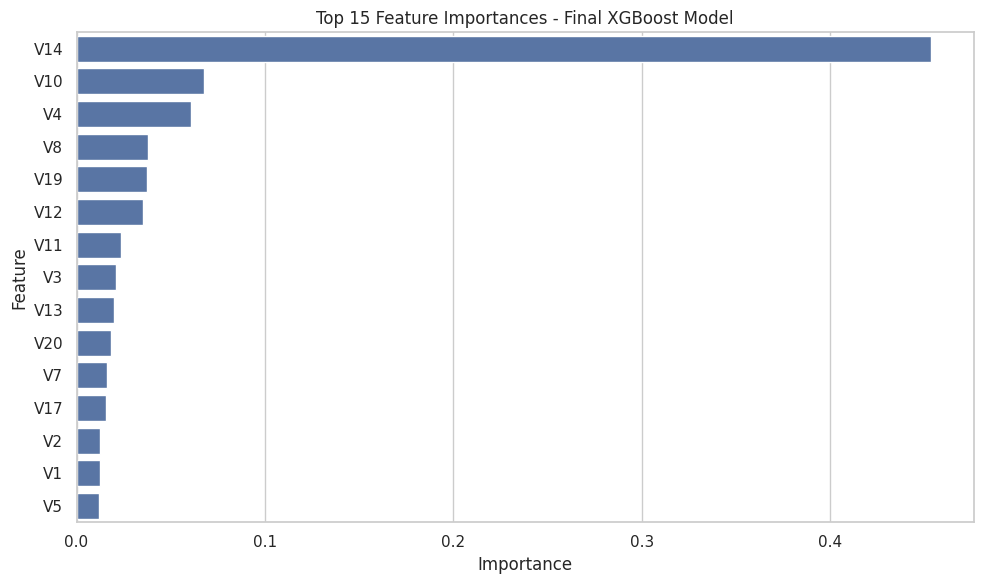

In [90]:
# =============================================================================
# 5.2.1 Compute native feature importance
# =============================================================================

# Define final-model feature names
if "full_feature_names" in globals():
    feature_names_final = full_feature_names
elif "X_train_scaled" in globals():
    feature_names_final = X_train_scaled.columns.tolist()
else:
    raise ValueError("Feature names for the final model are not available.")

# Build native feature importance table
native_importance_df = pd.DataFrame({
    "Feature": feature_names_final,
    "Importance": final_model.feature_importances_
}).sort_values(by="Importance", ascending=False).reset_index(drop=True)

print("Native Feature Importance:")
display(native_importance_df.head(15).round(4))

# Visualize top native feature importance
plt.figure(figsize=(10, 6))
sns.barplot(
    data=native_importance_df.head(15),
    x="Importance",
    y="Feature"
)
plt.title("Top 15 Feature Importances - Final XGBoost Model")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()

Installing SHAP...
SHAP installed successfully.
Global SHAP Importance:


,Feature,Mean_Abs_SHAP
0,V14,2.3483
1,V4,1.9168
2,V12,1.3275
3,V10,0.9799
4,V11,0.8163
5,V3,0.8111
6,V8,0.6223
7,V26,0.5018
8,V28,0.4967
9,V5,0.4637


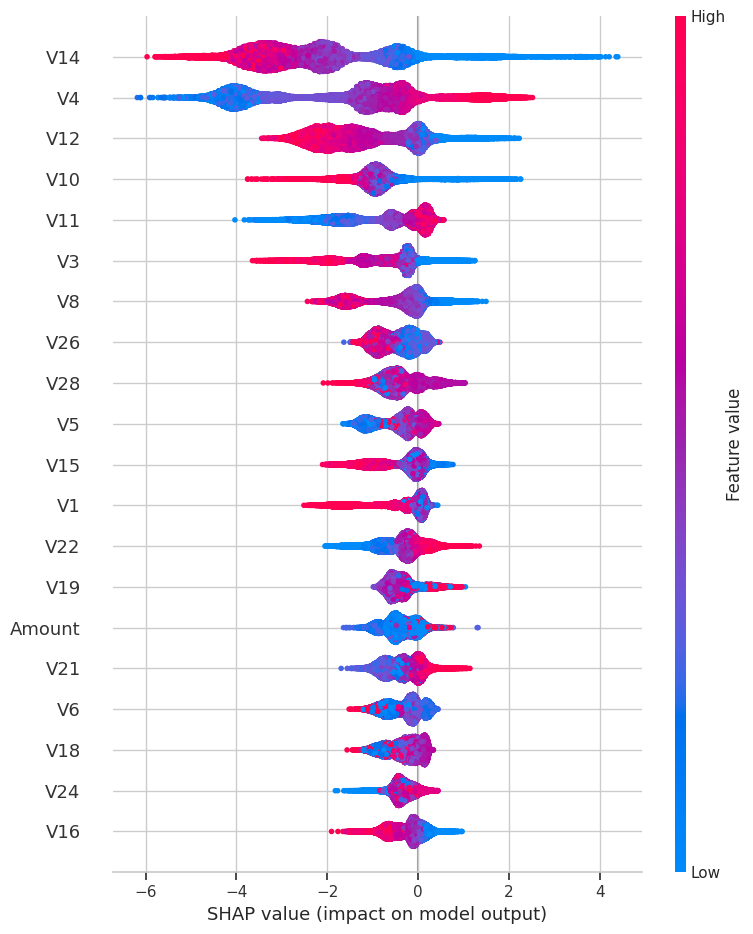

In [92]:
# =============================================================================
# 5.2.2 Compute SHAP global importance
# =============================================================================

# Import SHAP
import sys
import subprocess

try:
    import shap
except ImportError:
    print("Installing SHAP...")
    subprocess.check_call([sys.executable, "-m", "pip", "install", "shap"])
    import shap
    print("SHAP installed successfully.")

# Build SHAP explainer
shap_explainer = shap.TreeExplainer(final_model)

# Compute SHAP values
shap_values = shap_explainer.shap_values(X_eval)

# Handle binary-class output shape consistently
if isinstance(shap_values, list):
    shap_values_final = shap_values[1]
else:
    shap_values_final = shap_values

# Build global SHAP importance table
global_shap_importance_df = pd.DataFrame({
    "Feature": feature_names_final,
    "Mean_Abs_SHAP": np.abs(shap_values_final).mean(axis=0)
}).sort_values(by="Mean_Abs_SHAP", ascending=False).reset_index(drop=True)

print("Global SHAP Importance:")
display(global_shap_importance_df.head(15).round(4))

# Visualize global SHAP importance
shap.summary_plot(
    shap_values_final,
    X_eval,
    feature_names=feature_names_final,
    show=True
)

Top Positive SHAP Contributions - Fraud Case:


,Feature,Feature_Value,SHAP_Value
0,V14,-4.4930,3.7319
1,V10,-2.5811,1.6927
2,V12,-2.9223,1.6764
3,V4,2.8229,1.3289
4,V7,-2.1154,0.9197
5,V17,-3.3559,0.5873
6,V11,3.1433,0.3341
7,V16,-1.3072,0.2729
8,V21,0.7147,0.2502
9,V1,-1.1900,0.0115


Top Negative SHAP Contributions - Fraud Case:


,Feature,Feature_Value,SHAP_Value
35,V8,1.1903,-1.2216
34,Hour_Proxy,-2.4112,-1.0917
33,V23,-0.7431,-0.5198
32,Amount,-0.3596,-0.5090
31,V2,1.1867,-0.4451
30,V28,-0.4427,-0.3879
29,V20,0.1662,-0.3736
28,V27,0.6643,-0.3502
27,V5,-0.3877,-0.3363
26,V26,0.3688,-0.2960


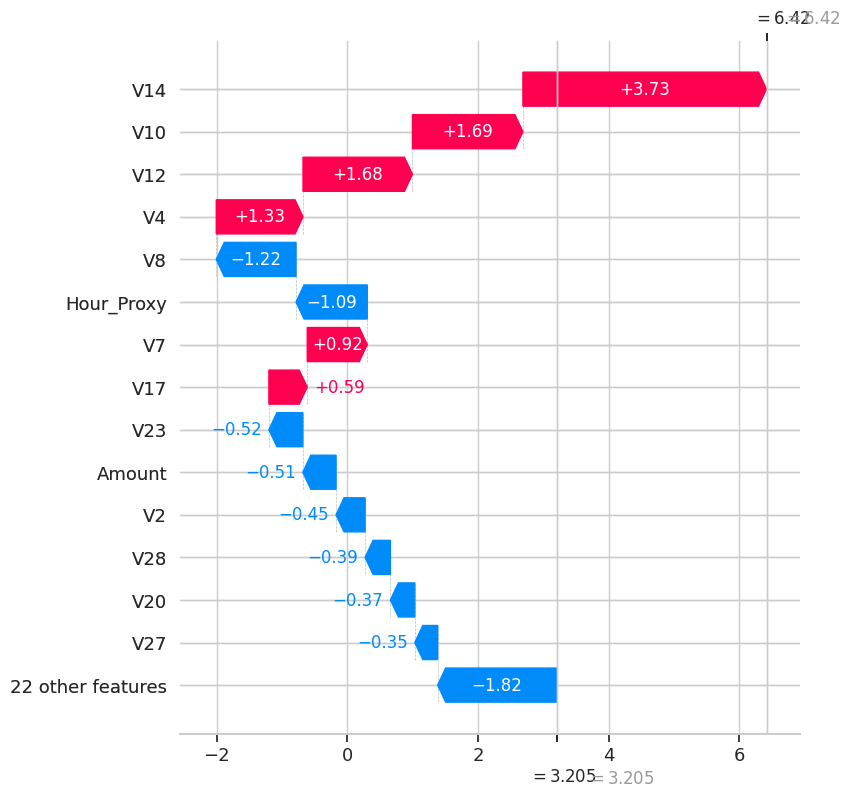

In [96]:
# =============================================================================
# 5.2.3 Generate local SHAP explanation for fraud case
# =============================================================================

# Identify correctly predicted fraud cases
fraud_case_indices = evaluation_df[
    (evaluation_df["y_true"] == 1) & (evaluation_df["y_pred"] == 1)
].index.sort_values() # Sort indices for reproducibility

if len(fraud_case_indices) == 0:
    raise ValueError("No correctly predicted fraud case found for local SHAP explanation.")

selected_fraud_idx = fraud_case_indices[0]

# Get the positional index for shap_values_final
pos_fraud_idx = X_eval.index.get_loc(selected_fraud_idx)

# Build local SHAP contribution table
fraud_local_shap_df = pd.DataFrame({
    "Feature": feature_names_final,
    "Feature_Value": X_eval.loc[selected_fraud_idx].values, # X_eval.loc uses the original index correctly
    "SHAP_Value": shap_values_final[pos_fraud_idx] # Use positional index for shap_values_final
}).sort_values(by="SHAP_Value", ascending=False).reset_index(drop=True)

print("Top Positive SHAP Contributions - Fraud Case:")
display(fraud_local_shap_df.head(10).round(4))

print("Top Negative SHAP Contributions - Fraud Case:")
display(fraud_local_shap_df.sort_values(by="SHAP_Value", ascending=True).head(10).round(4))

# Visualize local SHAP explanation
shap.plots._waterfall.waterfall_legacy(
    shap_explainer.expected_value,
    shap_values_final[pos_fraud_idx], # Use positional index here as well
    feature_names=feature_names_final,
    max_display=15
)

Top Positive SHAP Contributions - Legitimate Case:


,Feature,Feature_Value,SHAP_Value
0,V3,-3.9439,0.8017
1,V7,-0.6540,0.1717
2,V23,0.3993,0.0137
3,Is_Night,-0.3018,0.0000
4,Is_High_Amount,-0.2292,-0.0005
5,V18,0.3024,-0.0077
6,V24,-1.9217,-0.0126
7,Log_Amount,-0.5994,-0.0685
8,Hour_Sin,0.7741,-0.0791
9,V17,-0.1736,-0.1137


Top Negative SHAP Contributions - Legitimate Case:


,Feature,Feature_Value,SHAP_Value
35,V4,-1.7789,-4.3376
34,V14,1.1695,-3.4041
33,V12,1.1488,-1.9436
32,V10,5.6367,-1.6770
31,V8,2.2142,-1.4051
30,V27,5.7172,-1.2969
29,V25,2.3005,-1.0575
28,V21,-0.3648,-0.9084
27,V5,-1.1040,-0.8859
26,V6,-1.1332,-0.8570


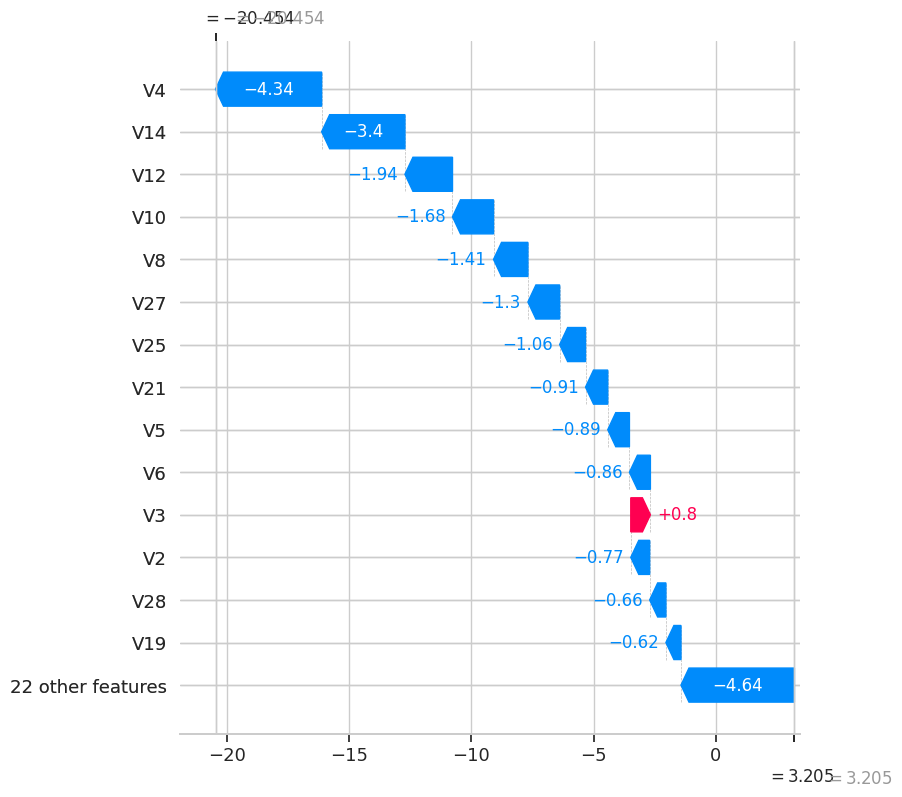

In [98]:
# =============================================================================
# Step 5: Critical Thinking, Ethical AI & Bias Auditing
# 5.2.4 Generate local SHAP explanation for legitimate case
# =============================================================================

# Identify correctly predicted legitimate cases
legit_case_indices = evaluation_df[
    (evaluation_df["y_true"] == 0) & (evaluation_df["y_pred"] == 0)
].index.sort_values()

if len(legit_case_indices) == 0:
    raise ValueError("No correctly predicted legitimate case found for local SHAP explanation.")

# Use the user-specified legitimate case index if it's a valid TN
user_specified_legit_idx = 191124
if user_specified_legit_idx in legit_case_indices:
    selected_legit_idx = user_specified_legit_idx
else:
    print(f"Warning: User-specified legitimate index {user_specified_legit_idx} is not a correctly predicted legitimate case. Using default selected index.")
    selected_legit_idx = legit_case_indices[0]

# Get the positional index for shap_values_final
pos_legit_idx = X_eval.index.get_loc(selected_legit_idx)

# Build local SHAP contribution table
legit_local_shap_df = pd.DataFrame({
    "Feature": feature_names_final,
    "Feature_Value": X_eval.loc[selected_legit_idx].values,
    "SHAP_Value": shap_values_final[pos_legit_idx] # Corrected from selected_legit_idx
}).sort_values(by="SHAP_Value", ascending=False).reset_index(drop=True)

print("Top Positive SHAP Contributions - Legitimate Case:")
display(legit_local_shap_df.head(10).round(4))

print("Top Negative SHAP Contributions - Legitimate Case:")
display(legit_local_shap_df.sort_values(by="SHAP_Value", ascending=True).head(10).round(4))

# Visualize local SHAP explanation
shap.plots._waterfall.waterfall_legacy(
    shap_explainer.expected_value,
    shap_values_final[pos_legit_idx], # Corrected from selected_legit_idx
    feature_names=feature_names_final,
    max_display=15
)

###**5.3. Model Performance Limitations**

In [100]:
# =============================================================================
# 5.3.1 Build evaluation dataset with outcomes and probabilities
# =============================================================================

# Build Step 5 evaluation dataset
step5_eval_df = evaluation_df.copy()

step5_eval_df["Outcome_Type"] = np.select(
    [
        (step5_eval_df["y_true"] == 1) & (step5_eval_df["y_pred"] == 1),
        (step5_eval_df["y_true"] == 1) & (step5_eval_df["y_pred"] == 0),
        (step5_eval_df["y_true"] == 0) & (step5_eval_df["y_pred"] == 1),
        (step5_eval_df["y_true"] == 0) & (step5_eval_df["y_pred"] == 0)
    ],
    [
        "True Positive",
        "False Negative",
        "False Positive",
        "True Negative"
    ],
    default="Unclassified"
)

print("Evaluation dataset with outcome labels:")
display(step5_eval_df.head())

print("\nOutcome counts:")
display(step5_eval_df["Outcome_Type"].value_counts().rename_axis("Outcome_Type").reset_index(name="Count"))

Evaluation dataset with outcome labels:


,y_true,y_pred,y_score,Outcome_Type
86568,0,0,0.0000,True Negative
251557,0,0,0.0000,True Negative
20232,0,0,0.0000,True Negative
68952,0,0,0.0000,True Negative
191852,0,0,0.0002,True Negative



Outcome counts:


,Outcome_Type,Count
0,True Negative,56648
1,True Positive,75
2,False Negative,20
3,False Positive,3


In [101]:
# =============================================================================
# 5.3.2 Analyze false positives and false negatives
# =============================================================================

# Subset false positives and false negatives
false_positive_df = step5_eval_df[step5_eval_df["Outcome_Type"] == "False Positive"].copy()
false_negative_df = step5_eval_df[step5_eval_df["Outcome_Type"] == "False Negative"].copy()

# Summarize error counts
error_summary_df = pd.DataFrame({
    "Error_Type": ["False Positives", "False Negatives"],
    "Count": [len(false_positive_df), len(false_negative_df)]
})

print("Error Summary:")
display(error_summary_df)

# Summarize score distribution by error type
error_score_summary_df = pd.DataFrame({
    "Error_Type": ["False Positives", "False Negatives"],
    "Mean_Score": [
        false_positive_df["y_score"].mean() if len(false_positive_df) > 0 else np.nan,
        false_negative_df["y_score"].mean() if len(false_negative_df) > 0 else np.nan
    ],
    "Min_Score": [
        false_positive_df["y_score"].min() if len(false_positive_df) > 0 else np.nan,
        false_negative_df["y_score"].min() if len(false_negative_df) > 0 else np.nan
    ],
    "Max_Score": [
        false_positive_df["y_score"].max() if len(false_positive_df) > 0 else np.nan,
        false_negative_df["y_score"].max() if len(false_negative_df) > 0 else np.nan
    ]
}).round(4)

print("\nError Score Summary:")
display(error_score_summary_df)

Error Summary:


,Error_Type,Count
0,False Positives,3
1,False Negatives,20



Error Score Summary:


,Error_Type,Mean_Score,Min_Score,Max_Score
0,False Positives,0.9534,0.9290,0.9999
1,False Negatives,0.0466,0.0000,0.5653


TP vs FN Signal Strength Summary:


,Outcome_Type,count,mean,median,min,max
0,False Negative,20,0.0466,0.0004,0.0000,0.5653
1,True Positive,75,0.9920,0.9999,0.8378,1.0000


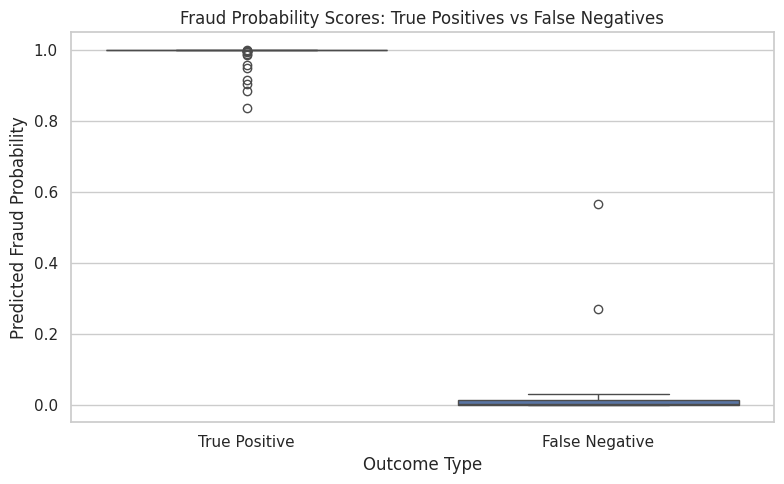

In [102]:
# =============================================================================
# 5.3.3 Compare TP vs FN signal strength
# =============================================================================

# Compare fraud-score strength for TP vs FN
tp_vs_fn_df = step5_eval_df[
    step5_eval_df["Outcome_Type"].isin(["True Positive", "False Negative"])
].copy()

signal_strength_summary_df = (
    tp_vs_fn_df
    .groupby("Outcome_Type")["y_score"]
    .agg(["count", "mean", "median", "min", "max"])
    .reset_index()
    .round(4)
)

print("TP vs FN Signal Strength Summary:")
display(signal_strength_summary_df)

# Visualize TP vs FN score distributions
plt.figure(figsize=(8, 5))
sns.boxplot(data=tp_vs_fn_df, x="Outcome_Type", y="y_score")
plt.title("Fraud Probability Scores: True Positives vs False Negatives")
plt.xlabel("Outcome Type")
plt.ylabel("Predicted Fraud Probability")
plt.tight_layout()
plt.show()

###**5.4. Fairness and Subgroup Limitations**

In [104]:
# =============================================================================
# 5.4.1 Create amount-band and time-band subgroup variables
# =============================================================================

# Confirm source dataframe for subgroup construction
# The X_test dataframe contains the unscaled features from Step 3 for the test set.
if "X_test" not in globals():
    raise ValueError("X_test dataframe is required for subgroup analysis.")

# Build bias-audit dataframe
bias_audit_df = X_test.copy()

# Align prediction outputs
bias_audit_df = bias_audit_df.loc[step5_eval_df.index].copy()
bias_audit_df["y_true"] = step5_eval_df["y_true"]
bias_audit_df["y_pred"] = step5_eval_df["y_pred"]
bias_audit_df["y_score"] = step5_eval_df["y_score"]

# Create amount-band subgroup
bias_audit_df["Amount_Band"] = pd.qcut(
    bias_audit_df["Amount"],
    q=4,
    labels=["Low Amount", "Lower-Mid Amount", "Upper-Mid Amount", "High Amount"],
    duplicates="drop"
)

# Create time-band subgroup
hour_source_col = "Hour_Proxy" if "Hour_Proxy" in bias_audit_df.columns else "Hour"

if hour_source_col not in bias_audit_df.columns:
    raise ValueError("Hour_Proxy or Hour is required to create time-band subgroup variables.")

bias_audit_df["Time_Band"] = pd.cut(
    bias_audit_df[hour_source_col],
    bins=[-1, 5, 11, 17, 23],
    labels=["Night", "Morning", "Afternoon", "Evening"]
)

print("Bias-audit dataset with subgroup variables:")
display(
    bias_audit_df[
        ["Amount", hour_source_col, "Amount_Band", "Time_Band", "y_true", "y_pred", "y_score"]
    ].head()
)


Bias-audit dataset with subgroup variables:


,Amount,Hour_Proxy,Amount_Band,Time_Band,y_true,y_pred,y_score
86568,11.5000,17,Lower-Mid Amount,Afternoon,0,0,0.0000
251557,1.9400,19,Low Amount,Evening,0,0,0.0000
20232,91.2800,8,High Amount,Morning,0,0,0.0000
68952,228.0000,14,High Amount,Afternoon,0,0,0.0000
191852,1.4100,11,Low Amount,Morning,0,0,0.0002


Subgroup Metrics by Amount Band:


,Group,Count,Positive_Prediction_Rate,Precision,Recall,False_Positive_Rate
0,High Amount,14187,0.0019,0.9630,0.7879,0.0001
1,Low Amount,14245,0.0023,0.9697,0.7273,0.0001
2,Lower-Mid Amount,14128,0.0004,0.8333,0.8333,0.0001
3,Upper-Mid Amount,14186,0.0008,1.0000,1.0000,0.0000


Subgroup Metrics by Time Band:


,Group,Count,Positive_Prediction_Rate,Precision,Recall,False_Positive_Rate
0,Afternoon,19284,0.0010,1.0000,0.6333,0.0000
1,Evening,18507,0.0008,0.8667,0.6842,0.0001
2,Morning,14063,0.0014,0.9474,0.9474,0.0001
3,Night,4892,0.0051,1.0000,0.9259,0.0000


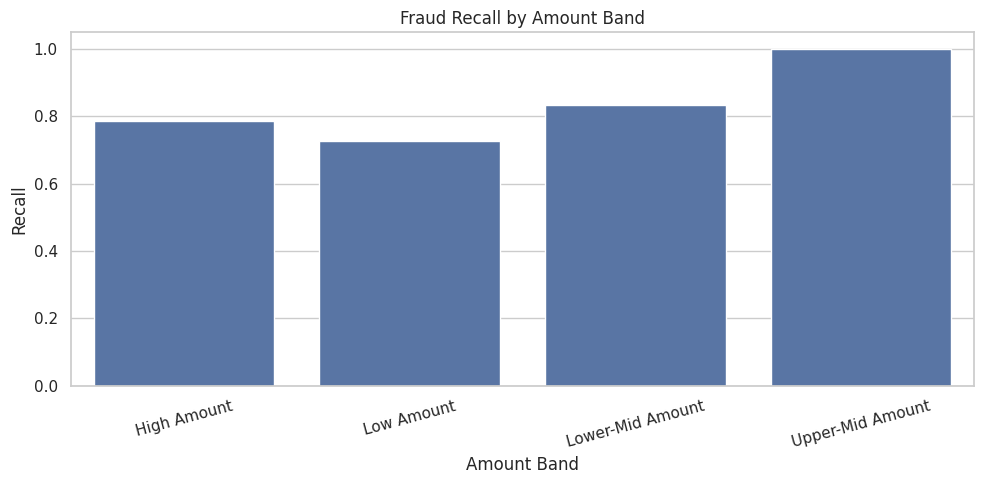

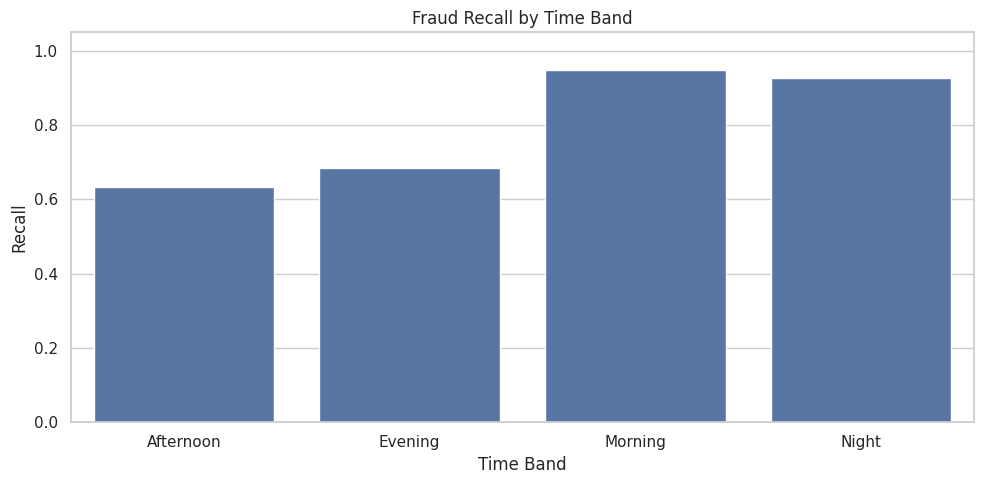

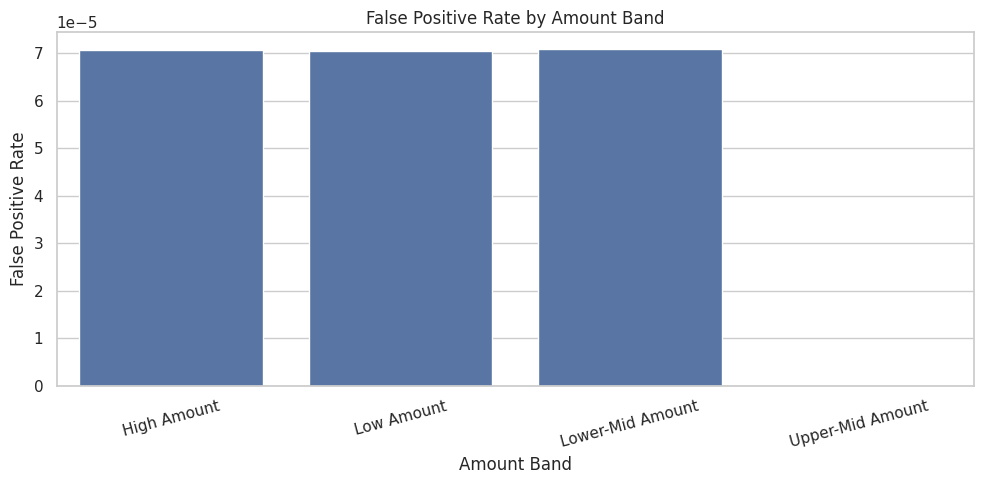

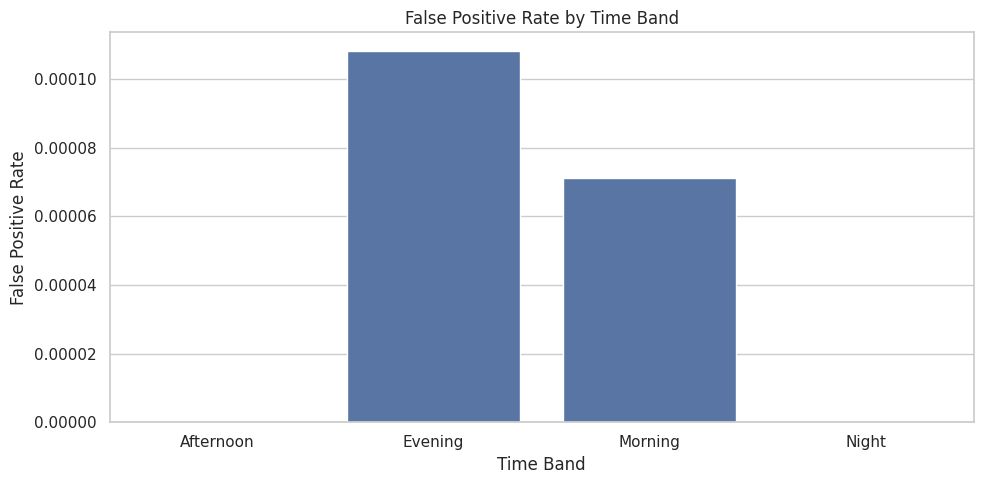

In [105]:
# =============================================================================
# 5.4.2 Evaluate subgroup recall and false positive rate
# =============================================================================

def compute_group_metrics(df, group_col):
    rows = []

    for group_name, group_df in df.groupby(group_col):
        tp = ((group_df["y_true"] == 1) & (group_df["y_pred"] == 1)).sum()
        tn = ((group_df["y_true"] == 0) & (group_df["y_pred"] == 0)).sum()
        fp = ((group_df["y_true"] == 0) & (group_df["y_pred"] == 1)).sum()
        fn = ((group_df["y_true"] == 1) & (group_df["y_pred"] == 0)).sum()

        recall = tp / (tp + fn) if (tp + fn) > 0 else np.nan
        false_positive_rate = fp / (fp + tn) if (fp + tn) > 0 else np.nan
        positive_prediction_rate = group_df["y_pred"].mean()
        precision = tp / (tp + fp) if (tp + fp) > 0 else np.nan

        rows.append({
            "Group": group_name,
            "Count": len(group_df),
            "Positive_Prediction_Rate": positive_prediction_rate,
            "Precision": precision,
            "Recall": recall,
            "False_Positive_Rate": false_positive_rate
        })

    return pd.DataFrame(rows).sort_values(by="Group").reset_index(drop=True)

amount_band_metrics_df = compute_group_metrics(bias_audit_df, "Amount_Band")
time_band_metrics_df = compute_group_metrics(bias_audit_df, "Time_Band")

print("Subgroup Metrics by Amount Band:")
display(amount_band_metrics_df.round(4))

print("Subgroup Metrics by Time Band:")
display(time_band_metrics_df.round(4))

# Visualize subgroup recall
plt.figure(figsize=(10, 5))
sns.barplot(data=amount_band_metrics_df, x="Group", y="Recall")
plt.title("Fraud Recall by Amount Band")
plt.xlabel("Amount Band")
plt.ylabel("Recall")
plt.ylim(0, 1.05)
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()

plt.figure(figsize=(10, 5))
sns.barplot(data=time_band_metrics_df, x="Group", y="Recall")
plt.title("Fraud Recall by Time Band")
plt.xlabel("Time Band")
plt.ylabel("Recall")
plt.ylim(0, 1.05)
plt.tight_layout()
plt.show()

# Visualize subgroup false positive rate
plt.figure(figsize=(10, 5))
sns.barplot(data=amount_band_metrics_df, x="Group", y="False_Positive_Rate")
plt.title("False Positive Rate by Amount Band")
plt.xlabel("Amount Band")
plt.ylabel("False Positive Rate")
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()

plt.figure(figsize=(10, 5))
sns.barplot(data=time_band_metrics_df, x="Group", y="False_Positive_Rate")
plt.title("False Positive Rate by Time Band")
plt.xlabel("Time Band")
plt.ylabel("False Positive Rate")
plt.tight_layout()
plt.show()

In [106]:
# =============================================================================
# 5.4.3 Compute proxy fairness metrics
# =============================================================================

def compute_fairness_metrics(df, group_col):
    rows = []

    for group_name, group_df in df.groupby(group_col):
        tp = ((group_df["y_true"] == 1) & (group_df["y_pred"] == 1)).sum()
        tn = ((group_df["y_true"] == 0) & (group_df["y_pred"] == 0)).sum()
        fp = ((group_df["y_true"] == 0) & (group_df["y_pred"] == 1)).sum()
        fn = ((group_df["y_true"] == 1) & (group_df["y_pred"] == 0)).sum()

        rows.append({
            "Group": group_name,
            "Count": len(group_df),
            "Actual_Fraud_Count": int(group_df["y_true"].sum()),
            "Positive_Prediction_Rate": group_df["y_pred"].mean(),
            "True_Positive_Rate": tp / (tp + fn) if (tp + fn) > 0 else np.nan,
            "False_Positive_Rate": fp / (fp + tn) if (fp + tn) > 0 else np.nan
        })

    return pd.DataFrame(rows).sort_values(by="Group").reset_index(drop=True)

amount_fairness_df = compute_fairness_metrics(bias_audit_df, "Amount_Band")
time_fairness_df = compute_fairness_metrics(bias_audit_df, "Time_Band")

print("Proxy Fairness Metrics by Amount Band:")
display(amount_fairness_df.round(4))

print("Proxy Fairness Metrics by Time Band:")
display(time_fairness_df.round(4))

Proxy Fairness Metrics by Amount Band:


,Group,Count,Actual_Fraud_Count,Positive_Prediction_Rate,True_Positive_Rate,False_Positive_Rate
0,High Amount,14187,33,0.0019,0.7879,0.0001
1,Low Amount,14245,44,0.0023,0.7273,0.0001
2,Lower-Mid Amount,14128,6,0.0004,0.8333,0.0001
3,Upper-Mid Amount,14186,12,0.0008,1.0000,0.0000


Proxy Fairness Metrics by Time Band:


,Group,Count,Actual_Fraud_Count,Positive_Prediction_Rate,True_Positive_Rate,False_Positive_Rate
0,Afternoon,19284,30,0.0010,0.6333,0.0000
1,Evening,18507,19,0.0008,0.6842,0.0001
2,Morning,14063,19,0.0014,0.9474,0.0001
3,Night,4892,27,0.0051,0.9259,0.0000


In [108]:
# =============================================================================
# 5.4.4 Summarize fairness gaps
# =============================================================================

def build_gap_summary(fairness_df, grouping_name):
    return pd.DataFrame({
        "Proxy_Grouping": [grouping_name, grouping_name, grouping_name],
        "Metric": [
            "Positive_Prediction_Rate",
            "True_Positive_Rate",
            "False_Positive_Rate"
        ],
        "Gap_Max_Minus_Min": [
            fairness_df["Positive_Prediction_Rate"].max() - fairness_df["Positive_Prediction_Rate"].min(),
            fairness_df["True_Positive_Rate"].max() - fairness_df["True_Positive_Rate"].min(),
            fairness_df["False_Positive_Rate"].max() - fairness_df["False_Positive_Rate"].min()
        ]
    })

amount_gap_summary_df = build_gap_summary(amount_fairness_df, "Amount Band")
time_gap_summary_df = build_gap_summary(time_fairness_df, "Time Band")

fairness_gap_summary_df = pd.concat(
    [amount_gap_summary_df, time_gap_summary_df],
    ignore_index=True
).round(4)

print("Fairness Gap Summary:")
display(fairness_gap_summary_df)

# Build equalized-odds proxy tables
amount_equalized_odds_df = amount_fairness_df[
    ["Group", "Actual_Fraud_Count", "True_Positive_Rate", "False_Positive_Rate"]
].copy()

time_equalized_odds_df = time_fairness_df[
    ["Group", "Actual_Fraud_Count", "True_Positive_Rate", "False_Positive_Rate"]
].copy()

print("\nEqualized-Odds Proxy Table by Amount Band:")
display(amount_equalized_odds_df.round(4))

print("\nEqualized-Odds Proxy Table by Time Band:")
display(time_equalized_odds_df.round(4))

Fairness Gap Summary:


,Proxy_Grouping,Metric,Gap_Max_Minus_Min
0,Amount Band,Positive_Prediction_Rate,0.0019
1,Amount Band,True_Positive_Rate,0.2727
2,Amount Band,False_Positive_Rate,0.0001
3,Time Band,Positive_Prediction_Rate,0.0043
4,Time Band,True_Positive_Rate,0.3140
5,Time Band,False_Positive_Rate,0.0001



Equalized-Odds Proxy Table by Amount Band:


,Group,Actual_Fraud_Count,True_Positive_Rate,False_Positive_Rate
0,High Amount,33,0.7879,0.0001
1,Low Amount,44,0.7273,0.0001
2,Lower-Mid Amount,6,0.8333,0.0001
3,Upper-Mid Amount,12,1.0000,0.0000



Equalized-Odds Proxy Table by Time Band:


,Group,Actual_Fraud_Count,True_Positive_Rate,False_Positive_Rate
0,Afternoon,30,0.6333,0.0000
1,Evening,19,0.6842,0.0001
2,Morning,19,0.9474,0.0001
3,Night,27,0.9259,0.0000



Threshold Comparison by Amount Band:


,Group,Recall_050,False_Positive_Rate_050,Recall_075,False_Positive_Rate_075
0,High Amount,0.7879,0.0001,0.7879,0.0001
1,Low Amount,0.7500,0.0003,0.7273,0.0001
2,Lower-Mid Amount,0.8333,0.0001,0.8333,0.0001
3,Upper-Mid Amount,1.0000,0.0000,1.0000,0.0000



Threshold Comparison by Time Band:


,Group,Recall_050,False_Positive_Rate_050,Recall_075,False_Positive_Rate_075
0,Afternoon,0.6667,0.0001,0.6333,0.0000
1,Evening,0.6842,0.0002,0.6842,0.0001
2,Morning,0.9474,0.0001,0.9474,0.0001
3,Night,0.9259,0.0002,0.9259,0.0000


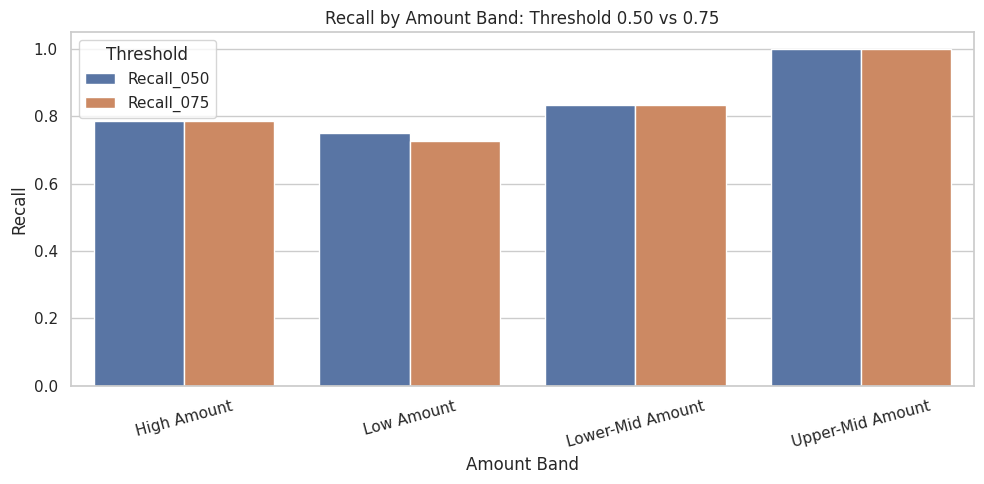

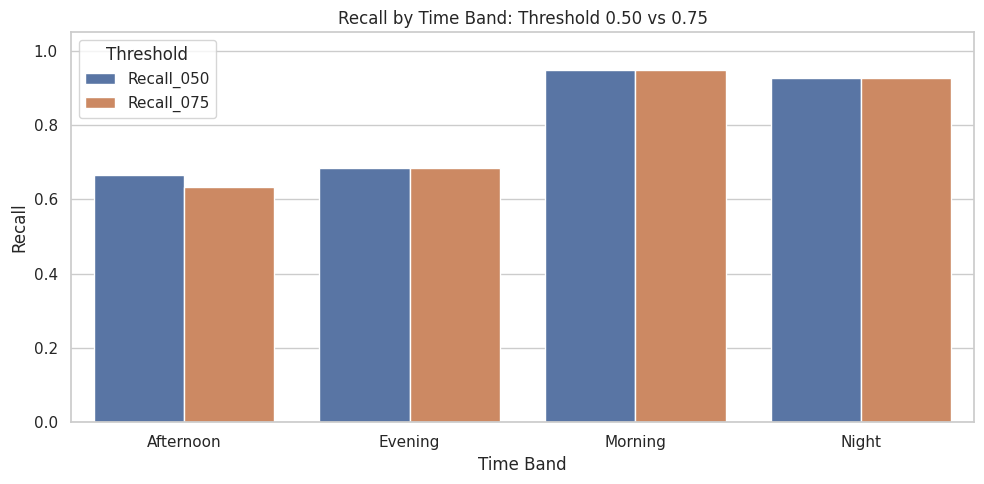

In [110]:
# =============================================================================
# 5.4.5 Compare subgroup behavior across thresholds
# =============================================================================

# Build threshold-comparison dataset
threshold_comparison_df = bias_audit_df.copy()
threshold_comparison_df["y_pred_050"] = (threshold_comparison_df["y_score"] >= 0.50).astype(int)
threshold_comparison_df["y_pred_075"] = threshold_comparison_df["y_pred"].copy()

def compute_threshold_group_metrics(df, group_col, pred_col):
    rows = []

    for group_name, group_df in df.groupby(group_col):
        tp = ((group_df["y_true"] == 1) & (group_df[pred_col] == 1)).sum()
        tn = ((group_df["y_true"] == 0) & (group_df[pred_col] == 0)).sum()
        fp = ((group_df["y_true"] == 0) & (group_df[pred_col] == 1)).sum()
        fn = ((group_df["y_true"] == 1) & (group_df[pred_col] == 0)).sum()

        rows.append({
            "Group": group_name,
            "Recall": tp / (tp + fn) if (tp + fn) > 0 else np.nan,
            "False_Positive_Rate": fp / (fp + tn) if (fp + tn) > 0 else np.nan
        })

    return pd.DataFrame(rows).sort_values(by="Group").reset_index(drop=True)

# Compare amount-band subgroup behavior
amount_metrics_050_df = compute_threshold_group_metrics(threshold_comparison_df, "Amount_Band", "y_pred_050")
amount_metrics_075_df = compute_threshold_group_metrics(threshold_comparison_df, "Amount_Band", "y_pred_075")

amount_threshold_comparison_df = amount_metrics_050_df.merge(
    amount_metrics_075_df,
    on="Group",
    suffixes=("_050", "_075")
)

print("\nThreshold Comparison by Amount Band:")
display(amount_threshold_comparison_df.round(4))

# Compare time-band subgroup behavior
time_metrics_050_df = compute_threshold_group_metrics(threshold_comparison_df, "Time_Band", "y_pred_050")
time_metrics_075_df = compute_threshold_group_metrics(threshold_comparison_df, "Time_Band", "y_pred_075")

time_threshold_comparison_df = time_metrics_050_df.merge(
    time_metrics_075_df,
    on="Group",
    suffixes=("_050", "_075")
)

print("\nThreshold Comparison by Time Band:")
display(time_threshold_comparison_df.round(4))

# Visualize recall shift by threshold
amount_recall_plot_df = amount_threshold_comparison_df.melt(
    id_vars="Group",
    value_vars=["Recall_050", "Recall_075"],
    var_name="Threshold",
    value_name="Recall"
)

time_recall_plot_df = time_threshold_comparison_df.melt(
    id_vars="Group",
    value_vars=["Recall_050", "Recall_075"],
    var_name="Threshold",
    value_name="Recall"
)

plt.figure(figsize=(10, 5))
sns.barplot(data=amount_recall_plot_df, x="Group", y="Recall", hue="Threshold")
plt.title("Recall by Amount Band: Threshold 0.50 vs 0.75")
plt.xlabel("Amount Band")
plt.ylabel("Recall")
plt.ylim(0, 1.05)
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()

plt.figure(figsize=(10, 5))
sns.barplot(data=time_recall_plot_df, x="Group", y="Recall", hue="Threshold")
plt.title("Recall by Time Band: Threshold 0.50 vs 0.75")
plt.xlabel("Time Band")
plt.ylabel("Recall")
plt.ylim(0, 1.05)
plt.tight_layout()
plt.show()